# Black-box benchmark with quarterly PD and Basel IRB (empirical, FRED)

Empirical counterpart of `03_blackbox_simulated_panel`: the end-to-end black box of the
methodology chapter (S3.2.3), `alpha_bb_{t+1} = g_theta(x_t)`, mapping the macro-financial
features directly to the allocation with **no PD intermediate**, trained on decision
regret (eq. 3.33 / 3.38). The harness is copied from
`test_predict_then_optimise_quarterly_pd_irb_v2` - same data loading, alignment, decision
environment, evaluation splits (`modern`, `stress`), metrics and plots - and the PTO
models plus the persistence baseline are **re-run here on identical expanding windows**,
so every Diebold-Mariano comparison shares the same test dates.

Empirical specifics of the black-box training signal (vs the simulated notebook):

- the capital requirement in the training loss is `k_irb(pd_a_realised_{t+1})` - the
  realised annualised PD's IRB charge - **matching how the empirical evaluation computes
  realised utility** (in sim it was `K_IRB_true_{t+1}`, matching the sim evaluation);
- the foresight oracle is the only oracle: there is no Bayes oracle and no
  regret decomposition empirically, so `regret` (vs perfect foresight) is the decision
  metric, exactly as in the empirical PTO notebook;
- everything is hindsight-outcome information (realised `c_{t+1}`, its implied IRB
  charge, and the ex-post optimal utility), the same status as PTO training on realised
  `c_{t+1}/LGD`.

Shared with the PTO notebook (fairness rule): features and timing, per-window
`StandardScaler` refit at every test date, alpha grid and utility constants, evaluation
against the foresight oracle, DM machinery, and architecture capacity / hyperparameter
budget (the policy nets reuse the same linear and two-hidden-layer MLP bodies with a
sigmoid head, eq. 3.30-3.31, output read as `alpha`). Different by design: no prediction
stage, no NLL/MSE - the network **is** the decision rule.


In [ ]:
from __future__ import annotations

import time
from dataclasses import dataclass
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
except ImportError as exc:
    raise ImportError(
        "This notebook needs PyTorch for the linear and MLP PTO models. "
        "Install the project requirements or select the project kernel."
    ) from exc

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv").exists():
    ROOT = ROOT.parent

FIGURES_DIR = ROOT / "empirical" / "figures" / "blackbox"
RESULTS_DIR = ROOT / "empirical" / "results" / "blackbox"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"Project root: {ROOT}")
print(f"Figures: {FIGURES_DIR.relative_to(ROOT)}")
print(f"Results: {RESULTS_DIR.relative_to(ROOT)}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Figures: figures/blackbox_pd_irb_v2
Results: empirical/results/blackbox


## Configuration

`CHARGE_OFF_CONVERSION = "simple"` inverts FRED's simple x4 annualisation, which is the
correct inverse for these series; `"compound"` remains available if the source were treated
as a compounded annual rate (the numerical difference at these PD levels is under 1%
relative). `TARGET_TRANSFORM = "logit"` trains on logit(PD) with a raw-score output head;
set `"level"` to reproduce the original sigmoid + level-space MSE behaviour.
`MLP_SEEDS` controls the ensemble size; MLP runtime scales linearly in the number of seeds.
The `stress` split retrains from 2006Q1 onward and roughly doubles total runtime — drop it
from `EVAL_SPLITS` for quick iterations.
The `LOSS` / `NLL_*` / `TARGET_TRANSFORM` switches govern the **PTO predictor only**,
re-run here unchanged for the aligned comparison (`NLL_RHO_MODE = "auto"` stays the
empirical default). The black box does not predict PD and does not use the NLL; it trains
on realised regret (see the dedicated section below). `BB_SEEDS` / `BB_MODEL_CFG` pin the
black box to the same seed-ensemble effort and capacity/optimiser/early-stopping budget
as the PTO MLP (fairness rule). Runtime roughly doubles versus the PTO notebook because
the black-box linear + MLP ensemble train at every window as well.


In [ ]:
# Data conventions
CHARGE_OFF_IS_PERCENT = True
# FRED annualises quarterly net charge-offs with a simple x4, so "simple" (/4) is the
# correct inverse of the source convention. "compound" kept as an alternative.
CHARGE_OFF_CONVERSION = "simple"
HORIZON = 1
DATE_COL = "DATE"
TARGET_COL = "charge_off_rate"

# Feature policy: the current-quarter charge-off c_q is realised by decision time
# (start of t+1), modulo a reporting lag. Set False to revert to lag-1 only.
INCLUDE_CURRENT_CQ = True

# Decision and Basel constants
LGD = 0.45
M = 2.5
K1 = 1.0
LEVERAGE = 10.0
Y_BAR = 0.0168
LAMBDA = 10.0

# Basel corporate PD floor (0.03%), applied inside k_irb_from_annual_pd.
APPLY_PD_FLOOR = True
PD_FLOOR = 3e-4

PD_Q_CLIP_LOW = 1e-6
PD_Q_CLIP_HIGH = 0.99
PD_A_CLIP_LOW = 1e-6
PD_A_CLIP_HIGH = 0.99
ALPHA_GRID = np.linspace(0.0, 1.0, 101)

# Modelling choices
TARGET_TRANSFORM = "logit"  # "logit" or "level" (original behaviour)
MLP_SEEDS = (42, 43, 44, 45, 46)  # MLP seed ensemble; use (42,) to disable

# Training loss. "nll_vasicek" fits PD by maximum likelihood under the assumption that
# realised charge-off rates are Vasicek draws given PD, with correlation = Basel R times
# NLL_RHO_SCALE. Unlike logit-space MSE (which targets the conditional MEDIAN of the
# realisation), the NLL targets the MEAN PD. Caveat: the aggregate FRED series,
# conditioned on rich macro features, carries far less residual noise than full Basel
# rho implies, so NLL_RHO_SCALE = 1.0 may inflate small PDs (roughly by the inverse
# median map, ~2-2.5x at rho ~ 0.2). Reduce NLL_RHO_SCALE or set LOSS = "mse" to compare.
LOSS = "nll_vasicek"  # "nll_vasicek" or "mse"
# "auto" estimates the residual probit-space variance per training window (OLS, no
# look-ahead) and sets rho_eff = s2 / (1 + s2): the likelihood noise the data actually
# exhibits given the features. Recommended for the aggregate FRED series, where full
# Basel rho drastically overstates residual noise and inflates predictions ~2-2.5x.
# "basel" uses rho = NLL_RHO_SCALE * BaselR(pd_a_hat).
NLL_RHO_MODE = "auto"  # "auto" or "basel"
NLL_RHO_SCALE = 1.0    # only used when NLL_RHO_MODE == "basel"

# Evaluation splits: separate expanding-window experiments.
EVAL_SPLITS = {
    "modern": {"initial_train_frac": 0.75},
    "stress": {"first_test_date": "2006-01-01"},
}

@dataclass
class ModelConfig:
    hidden_dim: int = 16
    lr: float = 1e-3
    weight_decay: float = 1e-4
    batch_size: int = 16
    epochs: int = 500
    patience: int = 75
    val_frac: float = 0.2
    seed: int = 42

MODEL_CFG = ModelConfig()

# ---- Black-box additions ---------------------------------------------------------------
# The black box maps features directly to the allocation alpha and trains on realised
# decision regret. The LOSS / NLL_* / TARGET_TRANSFORM switches above govern the PTO
# predictor ONLY and never touch the black box.
BB_SEEDS = MLP_SEEDS            # same seed-ensemble effort as the PTO MLP (fairness rule)
BB_MODEL_CFG = MODEL_CFG        # identical capacity / optimiser / early-stopping budget
print(f"Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised "
      f"regret with K = k_irb(pd_a_realised); seeds {BB_SEEDS}; same ModelConfig as PTO.")


Black box: policy net (linear + MLP, sigmoid head -> alpha), trained on realised regret with K = k_irb(pd_a_realised); seeds (42, 43, 44, 45, 46); same ModelConfig as PTO.


## Assumptions and caveats

These are held fixed by design; each materially shapes the results and should be restated
wherever results are reported.

- **Constant LGD = 0.45.** Realised PD is backed out as `c_q / LGD`, so "PD" here is a
  rescaled charge-off rate. LGD is procyclical in reality and Basel requires downturn LGD.
- **Corporate IRB curve on an aggregate charge-off series.** The asset-correlation function,
  maturity adjustment, and 0.03% floor are the wholesale/corporate ones. If the underlying
  FRED series is retail/consumer, the retail risk-weight functions (different correlation,
  no maturity adjustment) would apply.
- **Point-in-time PD in a through-the-cycle formula.** Next-quarter PD is annualised as
  `1-(1-pd_q)^4` (independence across quarters) and fed into the IRB formula, making capital
  procyclical; Basel intends TTC PDs.
- **Constant quarterly yield `Y_BAR` and constant leverage** regardless of the rate
  environment.
- **Final-vintage macro data.** Features use revised series, and quarter-t values (e.g. GDP)
  are not published until well into t+1 — a mild look-ahead relative to real-time
  deployment. Including `c_q` as a feature likewise assumes the quarter-t charge-off is
  observable at decision time; set `INCLUDE_CURRENT_CQ = False` to enforce a full
  one-quarter reporting lag.
- **Oracle regret** uses per-period perfect foresight of both `c_q` and the annualised PD
  entering the capital requirement, so regret mixes forecast error with capital-requirement
  foresight.
- **Capital buffer add-on.** Committed capital is excluded from the available buffer;
  equivalently the requirement is `K_IRB + 1/LEVERAGE` per unit exposure, i.e. the
  regulatory minimum plus a fixed management buffer. Calibrated so the constraint binds
  in the interior of the allocation range - without it the constraint never binds for
  alpha in [0,1] and the decision is degenerate at alpha = 1.- **Black-box training signal is hindsight-outcome information only.** Per training
  sample it uses realised `c_q_{t+1}`, the realised annualised PD's IRB charge
  `k_irb(pd_a_realised_{t+1})`, and the foresight-oracle utility - the same information
  status as PTO training on realised `c_{t+1}/LGD`. These enter as training TARGETS only;
  the input features are identical to the PTO models', and constructed PD columns remain
  excluded.
- **The oracle-regret caveat above applies with extra force to the black box**: because
  it trains directly on foresight-oracle regret, its training signal mixes charge-off
  hindsight with capital-requirement hindsight in exactly the way the evaluation does.
  That is by construction (train and test objectives coincide) and is the intended
  contrast with PTO's decision-blind prediction stage.


## Quarterly PD, Basel IRB, and allocation objective

In [ ]:
def annual_chargeoff_to_quarterly(c_annual, conversion=CHARGE_OFF_CONVERSION):
    c_annual = np.asarray(c_annual, dtype=float)
    if conversion == "compound":
        return 1.0 - np.power(1.0 - c_annual, 1.0 / 4.0)
    if conversion == "simple":
        return c_annual / 4.0
    raise ValueError("CHARGE_OFF_CONVERSION must be 'compound' or 'simple'.")


def clip_pd_q(pd_q):
    return np.clip(np.asarray(pd_q, dtype=float), PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)


def clip_pd_a(pd_a):
    return np.clip(np.asarray(pd_a, dtype=float), PD_A_CLIP_LOW, PD_A_CLIP_HIGH)


def quarterly_pd_to_annual(pd_q):
    pd_q = clip_pd_q(pd_q)
    return clip_pd_a(1.0 - np.power(1.0 - pd_q, 4.0))


def k_irb_from_annual_pd(pd_a, lgd=LGD, m=M, apply_floor=APPLY_PD_FLOOR):
    # Basel IRB capital requirement per unit exposure. Input must be annual PD.
    pd_a = clip_pd_a(pd_a)
    if apply_floor:
        pd_a = np.maximum(pd_a, PD_FLOOR)
    exp_term = (1.0 - np.exp(-50.0 * pd_a)) / (1.0 - np.exp(-50.0))
    r = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
    b = np.square(0.11852 - 0.05478 * np.log(pd_a))
    maturity_adj = (1.0 + (m - 2.5) * b) / (1.0 - 1.5 * b)
    z = norm.ppf(pd_a) / np.sqrt(1.0 - r) + np.sqrt(r / (1.0 - r)) * norm.ppf(0.999)
    k_irb = lgd * (norm.cdf(z) - pd_a) * maturity_adj
    return np.maximum(k_irb, 0.0)


def allocation_utility(alpha, c_q, pd_a, leverage=LEVERAGE, y_bar=Y_BAR, lambda_penalty=LAMBDA, k1=K1, lgd=LGD, m=M):
    # U(alpha; c_q, pd_a), with pd_a used only for Basel IRB capital.
    # Buffer semantics (intentional): committed capital alpha*k1 is excluded from the
    # available buffer. Algebraically identical to requiring K_IRB plus a fixed
    # management buffer add-on of 1/LEVERAGE per unit exposure; this is what makes the
    # capital constraint bind in the interior of the alpha grid (without it the
    # constraint never binds on [0,1] and every model would choose alpha = 1).
    alpha = np.asarray(alpha, dtype=float)
    c_q = float(c_q)
    pd_a = float(clip_pd_a(pd_a))
    exposure = leverage * alpha * k1
    terminal_capital = k1 + exposure * (y_bar - c_q)
    committed_capital = alpha * k1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_from_annual_pd(pd_a, lgd=lgd, m=m) * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0.0)
    return terminal_capital - lambda_penalty * shortfall


def decision_components(alpha, c_q, pd_a):
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    k_irb = float(k_irb_from_annual_pd(pd_a))
    required_capital = k_irb * exposure
    shortfall = max(required_capital - available_buffer, 0.0)
    utility = terminal_capital - LAMBDA * shortfall
    return dict(exposure=exposure, terminal_capital=terminal_capital, committed_capital=committed_capital,
                available_buffer=available_buffer, required_capital=required_capital, shortfall=shortfall,
                utility=utility, k_irb=k_irb)


def optimise_alpha_grid(c_q, pd_a, alpha_grid=ALPHA_GRID):
    utilities = allocation_utility(alpha_grid, c_q=c_q, pd_a=pd_a)
    best_idx = int(np.argmax(utilities))
    return float(alpha_grid[best_idx]), float(utilities[best_idx])

## Load and align data

The forecasting row is `x_t -> PD_Q_{t+1}`; result columns are named for the realised
next-period outcome, because that is the period used for decision evaluation.

Features now include the current-quarter charge-off `c_q` (realised by decision time,
subject to a reporting lag — see the assumptions cell) alongside `c_q_lag1`. Constructed PD
columns (`pd_q`, `pd_a`) remain excluded: realised PD is built from charge-offs for the
target/evaluation convention, not treated as an observed signal.
After loading, the per-quarter foresight oracle (`alpha_oracle_next`,
`utility_oracle_next`) and the realised IRB charge `k_irb_realised_next` are precomputed
once: they are the black box's training signal and are identical to the quantities
`build_result_row` recomputes per test row.


In [ ]:
def load_quarterly_pd_panel(macro_csv, chargeoff_csv, date_col=DATE_COL, target_col=TARGET_COL, feature_cols=None, horizon=HORIZON):
    macro = pd.read_csv(macro_csv)
    charge = pd.read_csv(chargeoff_csv)
    macro[date_col] = pd.to_datetime(macro[date_col]).dt.to_period("Q").dt.start_time
    charge[date_col] = pd.to_datetime(charge[date_col]).dt.to_period("Q").dt.start_time

    if target_col not in charge.columns:
        raise ValueError(f"{target_col!r} not found in charge-off columns: {list(charge.columns)}")

    charge["c_annual_raw"] = pd.to_numeric(charge[target_col], errors="coerce")
    charge["c_annual_decimal"] = charge["c_annual_raw"] / 100.0 if CHARGE_OFF_IS_PERCENT else charge["c_annual_raw"]
    charge["c_q"] = annual_chargeoff_to_quarterly(charge["c_annual_decimal"].to_numpy())
    charge["pd_q"] = clip_pd_q(charge["c_q"].to_numpy() / LGD)
    charge["pd_a"] = quarterly_pd_to_annual(charge["pd_q"].to_numpy())

    keep_charge = [date_col, "c_annual_raw", "c_annual_decimal", "c_q", "pd_q", "pd_a"]
    df = pd.merge(macro, charge[keep_charge], on=date_col, how="inner").sort_values(date_col).reset_index(drop=True)

    # Observed autoregressive signals. PD columns are never features.
    df["c_q_lag1"] = df["c_q"].shift(1)

    df["target_date"] = df[date_col].shift(-horizon)
    df["c_annual_raw_next"] = df["c_annual_raw"].shift(-horizon)
    df["c_q_realised"] = df["c_q"].shift(-horizon)
    df["pd_q_realised"] = df["pd_q"].shift(-horizon)
    df["pd_a_realised"] = df["pd_a"].shift(-horizon)
    df["target_pd_q_next"] = df["pd_q_realised"]

    if feature_cols is None:
        exclude = {date_col, "c_annual_raw", "c_annual_decimal", "pd_q", "pd_a", "target_date",
                   "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"}
        if not INCLUDE_CURRENT_CQ:
            exclude.add("c_q")
        feature_cols = [c for c in df.columns if c not in exclude]
    else:
        feature_cols = list(feature_cols)

    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    required = feature_cols + ["c_q", "target_date", "c_annual_raw_next", "c_q_realised", "pd_q_realised", "pd_a_realised", "target_pd_q_next"]
    required = list(dict.fromkeys(required))
    df = df.dropna(subset=required).reset_index(drop=True)
    if len(df) < 30:
        raise ValueError(f"Only {len(df)} usable observations after alignment; check dates and missing values.")
    df.attrs["feature_cols"] = feature_cols
    return df

macro_csv = ROOT / "empirical" / "data" / "macro_panel_quarterly.csv"
chargeoff_csv = ROOT / "empirical" / "data" / "fred_loan_return_aligned.csv"
df = load_quarterly_pd_panel(macro_csv, chargeoff_csv)
feature_cols = df.attrs["feature_cols"]

print(f"Observations after alignment and one-step target: {len(df)}")
print(f"Feature date range: {df[DATE_COL].min().date()} to {df[DATE_COL].max().date()}")
print(f"Target date range: {df['target_date'].min().date()} to {df['target_date'].max().date()}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
assert "c_q_lag1" in feature_cols
assert ("c_q" in feature_cols) == INCLUDE_CURRENT_CQ
assert not any(col.startswith("pd_q") or col.startswith("pd_a") for col in feature_cols)
print(f"Lag features included: c_q_lag1{' and current-quarter c_q' if INCLUDE_CURRENT_CQ else ''}; PD columns excluded.")
display(df.head())

# Foresight-oracle allocation and utility per TARGET quarter (perfect hindsight of
# c_q_{t+1} and pd_a_realised_{t+1}; identical to build_result_row's recomputation).
# Hindsight-outcome information: used only as the black box's training signal, never as
# a feature.
_oracle = [optimise_alpha_grid(c_q=float(c), pd_a=float(p))
           for c, p in zip(df["c_q_realised"], df["pd_a_realised"])]
df["alpha_oracle_next"] = [a for a, _ in _oracle]
df["utility_oracle_next"] = [u for _, u in _oracle]
# Capital requirement entering the black-box training loss: the realised annualised PD's
# IRB charge, matching how the empirical evaluation computes realised utility.
df["k_irb_realised_next"] = k_irb_from_annual_pd(df["pd_a_realised"].to_numpy())
assert not set(["alpha_oracle_next", "utility_oracle_next", "k_irb_realised_next"]) & set(feature_cols)
print("Precomputed foresight oracle and realised K_IRB for the black-box training signal.")


Observations after alignment and one-step target: 142
Feature date range: 1990-07-01 to 2025-10-01
Target date range: 1990-10-01 to 2026-01-01
Features (14): ['real_gdp_growth', 'unemployment_rate', 'industrial_production', 'real_disposable_personal_income', 'cpi', 'house_price_index', 'federal_funds_rate', 'treasury_10y_2y_spread', 'vix', 'corporate_bond_spread', 'senior_loan_officer_survey', 'excess_bond_premium', 'c_q', 'c_q_lag1']
Lag features included: c_q_lag1 and current-quarter c_q; PD columns excluded.


,DATE,real_gdp_growth,unemployment_rate,industrial_production,real_disposable_personal_income,cpi,house_price_index,federal_funds_rate,treasury_10y_2y_spread,vix,...,c_q,pd_q,pd_a,c_q_lag1,target_date,c_annual_raw_next,c_q_realised,pd_q_realised,pd_a_realised,target_pd_q_next
0,1990-07-01,0.3,5.700000,0.386851,0.014248,1.712502,0.607283,8.160000,0.602540,25.195556,...,0.003200,0.007111,0.028142,0.003575,1990-10-01,1.30,0.003250,0.007222,0.028577,0.007222
1,1990-10-01,-3.6,6.133333,-1.560018,-0.804251,1.683668,-0.390403,7.743333,0.800161,26.113281,...,0.003250,0.007222,0.028577,0.003200,1991-01-01,1.48,0.003700,0.008222,0.032485,0.008222
2,1991-01-01,-1.9,6.600000,-1.932577,0.306683,0.744790,0.833014,6.426667,0.987167,22.515833,...,0.003700,0.008222,0.032485,0.003250,1991-04-01,1.86,0.004650,0.010333,0.040697,0.010333
3,1991-04-01,3.2,6.833333,0.526353,0.748178,0.591864,0.660265,5.863333,1.231406,17.147031,...,0.004650,0.010333,0.040697,0.003700,1991-07-01,1.97,0.004925,0.010944,0.043064,0.010944
4,1991-07-01,2.0,6.866667,1.390822,0.383417,0.759342,0.195457,5.643333,1.428906,16.634219,...,0.004925,0.010944,0.043064,0.004650,1991-10-01,1.83,0.004575,0.010167,0.040051,0.010167


Precomputed foresight oracle and realised K_IRB for the black-box training signal.


## PTO models and training loop (verbatim from the PTO notebook)

Both models output a raw score whose sigmoid is the predicted quarterly PD. The loss
is selected by `LOSS`: Vasicek negative log-likelihood on probit targets (default;
targets the mean PD under the assumed Vasicek realisation noise) or MSE on
logit/level targets. Under `LOSS = "mse"`,
`TARGET_TRANSFORM` picks logit-space targets (well-conditioned) or level-space
targets (the original objective).
The output bias is initialised at logit(mean PD) of the pre-validation slice only.
Mini-batches are shuffled with a seeded generator; the train/validation split itself
remains chronological.

In [ ]:
def logit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return np.log(p / (1.0 - p))


def probit_np(p):
    p = np.clip(np.asarray(p, dtype=float), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW)
    return norm.ppf(p)


def torch_vasicek_nll(score, y_probit, rho_fixed=None):
    """Negative log-likelihood of realised rates under the Vasicek density,
    parameterised by the model's predicted PD (sigmoid of the raw score).

    In probit space the Vasicek model is Gaussian:
        ndtri(x) | p ~ N( ndtri(p) / sqrt(1 - rho), rho / (1 - rho) ),
    with rho = NLL_RHO_SCALE * BaselR(annualised p). Terms not involving the
    prediction are dropped, except the log-variance, which depends on p through rho.
    Maximising this likelihood targets the MEAN parameter p.
    """
    pd_q = torch.sigmoid(score).clamp(PD_Q_CLIP_LOW, PD_Q_CLIP_HIGH)
    if rho_fixed is not None:
        rho = torch.as_tensor(float(rho_fixed))
    else:
        pd_a = (1.0 - torch.pow(1.0 - pd_q, 4.0)).clamp(PD_A_CLIP_LOW, PD_A_CLIP_HIGH)
        exp_term = (1.0 - torch.exp(-50.0 * pd_a)) / (1.0 - float(np.exp(-50.0)))
        rho = 0.12 * exp_term + 0.24 * (1.0 - exp_term)
        rho = torch.clamp(NLL_RHO_SCALE * rho, 1e-4, 0.999)
    mu = torch.special.ndtri(pd_q) / torch.sqrt(1.0 - rho)
    var = rho / (1.0 - rho)
    return torch.mean(0.5 * torch.log(var) + (y_probit - mu) ** 2 / (2.0 * var))


class PDForecaster(nn.Module):
    # Outputs a raw score; predicted quarterly PD is sigmoid(score).
    def __init__(self, input_dim, model_type, hidden_dim=16):
        super().__init__()
        if model_type == "linear":
            self.net = nn.Linear(input_dim, 1)
        elif model_type == "mlp":
            self.net = nn.Sequential(nn.Linear(input_dim, hidden_dim), nn.ReLU(),
                                     nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 1))
        else:
            raise ValueError("model_type must be 'linear' or 'mlp'.")

    def forward(self, x):
        return self.net(x).squeeze(-1)


def init_output_bias_for_target(model, y_pre_val):
    # Bias starts at logit(mean PD) of the PRE-validation slice only, so validation
    # targets used for early stopping never influence initialisation.
    y_mean = float(np.clip(np.mean(y_pre_val), PD_Q_CLIP_LOW, 1.0 - PD_Q_CLIP_LOW))
    logit_mean = float(np.log(y_mean / (1.0 - y_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_pd_model(x_train, y_train_pd_q, model_type, model_cfg, seed=None, return_history=False):
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    y_tr, y_val = y_train_pd_q[:train_size], y_train_pd_q[train_size:]
    if LOSS == "nll_vasicek":
        t_tr, t_val = probit_np(y_tr), probit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "logit":
        t_tr, t_val = logit_np(y_tr), logit_np(y_val)
    elif LOSS == "mse" and TARGET_TRANSFORM == "level":
        t_tr, t_val = y_tr, y_val
    else:
        raise ValueError("LOSS must be 'nll_vasicek' or 'mse'; TARGET_TRANSFORM must be 'logit' or 'level'.")

    train_ds = TensorDataset(torch.tensor(x_tr, dtype=torch.float32), torch.tensor(t_tr, dtype=torch.float32))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PDForecaster(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_target(model, y_tr)
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)
    mse_fn = nn.MSELoss()

    rho_fixed = None
    if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto":
        # Residual probit-space variance of the training window (pre-validation slice),
        # via OLS with intercept: rho_eff = s2 / (1 + s2) is the Vasicek correlation
        # implied by the noise the data actually shows given the features.
        X_ols = np.hstack([x_tr, np.ones((len(x_tr), 1))])
        beta_ols, *_ = np.linalg.lstsq(X_ols, t_tr, rcond=None)
        resid = t_tr - X_ols @ beta_ols
        dof = max(len(t_tr) - X_ols.shape[1], 1)
        s2 = float(resid @ resid) / dof
        rho_fixed = float(np.clip(s2 / (1.0 + s2), 1e-4, 0.5))

    def compute_loss(score, target):
        if LOSS == "nll_vasicek":
            return torch_vasicek_nll(score, target, rho_fixed=rho_fixed)
        pred = score if TARGET_TRANSFORM == "logit" else torch.sigmoid(score)
        return mse_fn(pred, target)

    x_val_t = torch.tensor(x_val, dtype=torch.float32)
    t_val_t = torch.tensor(t_val, dtype=torch.float32)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, tb in train_loader:
            optimiser.zero_grad()
            loss = compute_loss(model(xb), tb)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_loss = compute_loss(score_val, t_val_t).item()
            pd_q_val_np = clip_pd_q(torch.sigmoid(score_val).cpu().numpy())
        history.append({"epoch": epoch + 1, "model": model_type, "seed": seed,
                        "rho_eff": float("nan") if rho_fixed is None else rho_fixed,
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_loss),
                        "val_rmse_pd_q": float(np.sqrt(mean_squared_error(y_val, pd_q_val_np))),
                        "val_mae_pd_q": float(mean_absolute_error(y_val, pd_q_val_np)),
                        "val_mean_pd_q_hat": float(np.mean(pd_q_val_np))})

        if val_loss < best_val - 1e-12:
            best_val, stale_epochs = val_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_pd_q(model, x):
    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return clip_pd_q(np.atleast_1d(pred))


def train_mlp_ensemble(x_train, y_train_pd_q, model_cfg, seeds=MLP_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_pd_model(x_train, y_train_pd_q, "mlp", model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_pd_q_ensemble(models, x):
    preds = np.stack([predict_pd_q(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

## Black-box policy: features -> alpha, trained on realised regret

Objective (thesis eq. 3.33 / 3.38): mean realised regret over the training window,

    L_BB = (1/T) * sum_t [ U_oracle(t+1) - U(alpha_theta(x_t); c_q_{t+1}, k_irb(pd_a_realised_{t+1})) ]

`U_oracle` does not depend on theta, so minimising mean regret is equivalent to maximising
mean realised utility; regret is kept in the loss so training/validation curves read
directly as regret. Implementation notes (identical mechanics to the simulated notebook):

- **Architecture**: `PolicyNet = PDForecaster` - the identical linear / two-hidden-layer
  MLP bodies with a sigmoid head (eq. 3.30-3.31), output read as `alpha in [0, 1]`.
  Same `ModelConfig`, same seed ensemble as the PTO MLP (fairness rule).
- **Kink**: the shortfall `max(., 0)` is piecewise linear; torch subgradients handle it.
- **K in the training signal**: `k_irb(pd_a_realised_{t+1})` - the empirical convention,
  matching how realised utility is evaluated in this notebook (in sim: `K_IRB_true_{t+1}`,
  matching the sim evaluation). K enters the loss as a per-sample constant, not through
  theta, so no differentiable IRB formula is needed.
- **Early stopping on validation REGRET** (chronological tail split), mirroring
  `train_pd_model`'s mechanics with a different criterion by design. The output bias is
  initialised at the mean training-window oracle allocation, the analogue of the PTO
  models' target-mean initialisation (also hindsight-only information).
- **Grid snap at evaluation**: the continuous sigmoid output is snapped to the shared
  0.01 alpha grid so all models act in the identical decision environment; because the
  foresight oracle maximises over the same grid, regret is >= 0 exactly.
- **Harness entry at the ALPHA level**: `pd_q_hat` / `pd_a_hat` / `c_q_hat` / `k_irb_hat`
  are NaN, PD-accuracy metrics and the DM test on squared PD errors do not apply; regret
  metrics, the shortfall bind share, and the DM test on regret apply unchanged.

Because it trains across many realised quarters, the black box directly optimises
empirical expected utility without distributional assumptions - the intended contrast
with PTO's decision-blind prediction stage. Caveat for the write-up: with ~35-80 test
windows and short training samples, the empirical setting gives the black box far fewer
regret observations to learn from than the ~1000-quarter simulation; expect noisier
behaviour, especially in the `stress` split (the GFC is out-of-distribution for a
regret-trained policy just as it is for the MLP predictor).


In [ ]:
def torch_allocation_utility(alpha, c_q, k):
    """Differentiable counterpart of allocation_utility - same constants and the same
    intentional buffer semantics (committed capital alpha*K1 excluded from the buffer).
    The kinked shortfall max(., 0) is piecewise linear; torch subgradients handle it."""
    exposure = LEVERAGE * alpha * K1
    terminal_capital = K1 + exposure * (Y_BAR - c_q)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k * exposure
    shortfall = torch.clamp(required_capital - available_buffer, min=0.0)
    return terminal_capital - LAMBDA * shortfall


# Fairness rule: the policy network is architecturally identical to the PD forecaster -
# the same linear / two-hidden-layer MLP bodies and sigmoid head, output read as alpha.
PolicyNet = PDForecaster


def snap_alpha(alpha):
    """Snap continuous policy outputs to the shared decision grid so every model acts in
    the identical environment (and foresight regret is >= 0 exactly, since the oracle
    maximises over the same grid)."""
    alpha = np.atleast_1d(np.asarray(alpha, dtype=float))
    idx = np.abs(ALPHA_GRID[None, :] - alpha[:, None]).argmin(axis=1)
    return ALPHA_GRID[idx]


def init_output_bias_for_alpha(model, alpha_pre_val):
    # Mirror of init_output_bias_for_target: start the policy at the mean training-window
    # oracle allocation (hindsight-outcome info, same status as the regret target itself).
    a_mean = float(np.clip(np.mean(alpha_pre_val), 0.01, 0.99))
    logit_mean = float(np.log(a_mean / (1.0 - a_mean)))
    with torch.no_grad():
        if isinstance(model.net, nn.Linear):
            model.net.bias.fill_(logit_mean)
        else:
            model.net[-1].bias.fill_(logit_mean)


def train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_type,
                       model_cfg, seed=None, return_history=False):
    """Train alpha_theta(x) by minimising mean realised regret
    U_oracle(t+1) - U(alpha_theta(x_t); c_{t+1}, K_{t+1}) over the training window.
    U_oracle is constant in theta, so this equals maximising mean realised utility; it is
    kept in the loss so the train/val curves read directly as regret. Early stopping
    monitors VALIDATION REGRET on the chronological tail (same mechanics as
    train_pd_model, different criterion by design)."""
    seed = model_cfg.seed if seed is None else int(seed)
    torch.manual_seed(seed)
    np.random.seed(seed)
    n = x_train.shape[0]
    val_size = max(1, int(np.floor(model_cfg.val_frac * n)))
    train_size = n - val_size
    if train_size < 8:
        raise ValueError("Training set too small after validation split.")

    def to_t(a):
        return torch.tensor(np.asarray(a, dtype=float), dtype=torch.float32)

    x_tr, x_val = x_train[:train_size], x_train[train_size:]
    c_tr, c_val = c_next[:train_size], c_next[train_size:]
    k_tr, k_val = k_next[:train_size], k_next[train_size:]
    u_tr, u_val = u_oracle_next[:train_size], u_oracle_next[train_size:]

    train_ds = TensorDataset(to_t(x_tr), to_t(c_tr), to_t(k_tr), to_t(u_tr))
    loader_gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_ds, batch_size=model_cfg.batch_size, shuffle=True, generator=loader_gen)

    model = PolicyNet(input_dim=x_train.shape[1], model_type=model_type, hidden_dim=model_cfg.hidden_dim)
    init_output_bias_for_alpha(model, alpha_oracle_next[:train_size])
    optimiser = torch.optim.AdamW(model.parameters(), lr=model_cfg.lr, weight_decay=model_cfg.weight_decay)

    def regret_loss(score, cb, kb, ub):
        alpha = torch.sigmoid(score)
        return torch.mean(ub - torch_allocation_utility(alpha, cb, kb))

    x_val_t, c_val_t, k_val_t, u_val_t = to_t(x_val), to_t(c_val), to_t(k_val), to_t(u_val)
    best_state, best_val, stale_epochs, history = None, float("inf"), 0, []

    for epoch in range(model_cfg.epochs):
        model.train()
        batch_losses = []
        for xb, cb, kb, ub in train_loader:
            optimiser.zero_grad()
            loss = regret_loss(model(xb), cb, kb, ub)
            loss.backward()
            optimiser.step()
            batch_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            score_val = model(x_val_t)
            val_regret = regret_loss(score_val, c_val_t, k_val_t, u_val_t).item()
            alpha_val = torch.sigmoid(score_val).cpu().numpy()
        history.append({"epoch": epoch + 1, "model": f"blackbox_{model_type}", "seed": seed,
                        "rho_eff": float("nan"),
                        "train_loss": float(np.mean(batch_losses)), "val_loss": float(val_regret),
                        "val_rmse_pd_q": float("nan"), "val_mae_pd_q": float("nan"),
                        "val_mean_pd_q_hat": float("nan"),
                        "val_mean_alpha": float(np.mean(alpha_val))})

        if val_regret < best_val - 1e-12:
            best_val, stale_epochs = val_regret, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            stale_epochs += 1
        if stale_epochs >= model_cfg.patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return (model, pd.DataFrame(history)) if return_history else model


def predict_alpha(model, x):
    # Continuous policy output in [0, 1]; snapping to the grid happens in
    # build_result_row_alpha so ensemble averaging stays continuous.
    model.eval()
    with torch.no_grad():
        alpha = torch.sigmoid(model(torch.tensor(x, dtype=torch.float32))).cpu().numpy()
    return np.clip(np.atleast_1d(alpha), 0.0, 1.0)


def train_policy_ensemble(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, model_cfg,
                          seeds=BB_SEEDS, return_history=False):
    models, first_hist = [], None
    for i, s in enumerate(seeds):
        want_hist = return_history and i == 0
        out = train_policy_model(x_train, c_next, k_next, u_oracle_next, alpha_oracle_next, "mlp",
                                 model_cfg, seed=s, return_history=want_hist)
        if want_hist:
            model, first_hist = out
        else:
            model = out
        models.append(model)
    return models, first_hist


def predict_alpha_ensemble(models, x):
    preds = np.stack([predict_alpha(m, x) for m in models], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)


## Expanding-window evaluation

At each test date the scaler and models are refit on observations strictly before the
feature date. Three predictors run through the identical decision pipeline: the linear
model, the MLP seed ensemble (mean prediction), and a persistence baseline
`pd_q_hat = c_q_t / LGD`. Persistence is the reference point: a trained model that does not
beat it on regret adds no decision value over "assume next quarter looks like this quarter".

Two splits run as separate experiments: `modern` (last 25% of the sample) and `stress`
(test targets from 2006Q1, so the GFC is out-of-sample). The modern test window is contained
in the stress one; they are not independent samples.
The black box is trained at each test date on the **same expanding window and the same
fitted scaler** as the PTO models (`blackbox_linear` single seed, `blackbox_mlp` seed
ensemble whose continuous alphas are averaged before the grid snap). It enters result
collection through `build_result_row_alpha`: PD fields NaN, everything regret-side
identical. Five predictors therefore run through the identical decision pipeline.


In [ ]:
def build_result_row(base_row, pd_q_hat, model_name, split_name, pd_q_hat_std=float("nan")):
    pd_q_hat = float(clip_pd_q(pd_q_hat))
    c_q_hat = float(LGD * pd_q_hat)
    pd_a_hat = float(quarterly_pd_to_annual(pd_q_hat))
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])

    alpha_hat, _ = optimise_alpha_grid(c_q=c_q_hat, pd_a=pd_a_hat)
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    predicted_components = decision_components(alpha_hat, c_q=c_q_hat, pd_a=pd_a_hat)
    regret = utility_oracle - realised_components["utility"]

    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": pd_q_hat, "pd_q_hat_std": float(pd_q_hat_std), "pd_a_hat": pd_a_hat, "c_q_hat": c_q_hat,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": float(k_irb_from_annual_pd(pd_a_hat)),
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat, "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": predicted_components["shortfall"]}


def build_result_row_alpha(base_row, alpha_hat_raw, model_name, split_name, alpha_hat_std=float("nan")):
    """Black-box counterpart of build_result_row: enters the harness at the ALPHA level.
    There is no PD intermediate, so pd_q_hat / pd_a_hat / c_q_hat / k_irb_hat and the
    predicted-shortfall column are NaN; regret and the shortfall bind share apply
    unchanged. The continuous policy output is snapped to the shared alpha grid so the
    decision environment is identical across models."""
    alpha_hat = float(snap_alpha(float(alpha_hat_raw))[0])
    c_q_realised = float(base_row["c_q_realised"])
    pd_q_realised = float(base_row["pd_q_realised"])
    pd_a_realised = float(base_row["pd_a_realised"])
    alpha_oracle, utility_oracle = optimise_alpha_grid(c_q=c_q_realised, pd_a=pd_a_realised)
    realised_components = decision_components(alpha_hat, c_q=c_q_realised, pd_a=pd_a_realised)
    oracle_components = decision_components(alpha_oracle, c_q=c_q_realised, pd_a=pd_a_realised)
    regret = utility_oracle - realised_components["utility"]
    nan = float("nan")
    return {"split": split_name, "model": model_name, "date": pd.to_datetime(base_row["target_date"]),
            "feature_date": pd.to_datetime(base_row[DATE_COL]), "c_annual_raw": float(base_row["c_annual_raw_next"]),
            "c_q_lag1": float(base_row["c_q_lag1"]),
            "c_q_realised": c_q_realised, "pd_q_realised": pd_q_realised, "pd_a_realised": pd_a_realised,
            "pd_q_hat": nan, "pd_q_hat_std": nan, "pd_a_hat": nan, "c_q_hat": nan,
            "k_irb_realised": float(k_irb_from_annual_pd(pd_a_realised)), "k_irb_hat": nan,
            "alpha_oracle": alpha_oracle, "alpha_hat": alpha_hat,
            "alpha_hat_raw_bb": float(alpha_hat_raw), "alpha_hat_std_bb": float(alpha_hat_std),
            "utility_oracle": utility_oracle,
            "utility": realised_components["utility"], "regret": regret,
            "shortfall_oracle": oracle_components["shortfall"],
            "shortfall_realised_at_hat": realised_components["shortfall"],
            "shortfall_predicted_at_hat": nan}


def resolve_first_test_idx(df, split_cfg):
    if "initial_train_frac" in split_cfg:
        first_test_idx = int(np.floor(len(df) * float(split_cfg["initial_train_frac"])))
    elif "first_test_date" in split_cfg:
        mask = (df["target_date"] >= pd.Timestamp(split_cfg["first_test_date"])).to_numpy()
        if not mask.any():
            raise ValueError("first_test_date is after the last available target date.")
        first_test_idx = int(np.flatnonzero(mask)[0])
    else:
        raise ValueError("Split config needs 'initial_train_frac' or 'first_test_date'.")
    if first_test_idx < 30 or len(df) - first_test_idx < 5:
        raise ValueError(f"Split leaves too little data: first_test_idx={first_test_idx} of {len(df)}.")
    return first_test_idx


def run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg, model_cfg=MODEL_CFG, return_history=True):
    first_test_idx = resolve_first_test_idx(df, split_cfg)
    total = len(df) - first_test_idx
    print(f"[{split_name}] first test target: {pd.Timestamp(df['target_date'].iloc[first_test_idx]).date()}, "
          f"{total} windows, {first_test_idx} initial training obs")
    records, histories = [], []
    t0 = time.time()
    for test_idx in range(first_test_idx, len(df)):
        train_df = df.iloc[:test_idx]
        test_row = df.iloc[test_idx]
        scaler = StandardScaler()
        x_train = scaler.fit_transform(train_df[feature_cols].to_numpy(dtype=float))
        y_train = train_df["target_pd_q_next"].to_numpy(dtype=float)
        x_test = scaler.transform(test_row[feature_cols].to_numpy(dtype=float).reshape(1, -1))

        linear_model, linear_hist = train_pd_model(x_train, y_train, "linear", model_cfg, return_history=True)
        records.append(build_result_row(test_row, float(predict_pd_q(linear_model, x_test)[0]), "linear", split_name))

        mlp_models, mlp_hist = train_mlp_ensemble(x_train, y_train, model_cfg, return_history=True)
        mlp_mean, mlp_std = predict_pd_q_ensemble(mlp_models, x_test)
        records.append(build_result_row(test_row, float(mlp_mean[0]), "mlp", split_name, pd_q_hat_std=float(mlp_std[0])))

        # Persistence baseline: current-quarter implied PD carried forward, no training.
        records.append(build_result_row(test_row, float(clip_pd_q(test_row["c_q"] / LGD)), "persistence", split_name))

        # Black box: same window and scaler; targets are hindsight outcomes
        # (realised c_{t+1}, k_irb(pd_a_realised_{t+1}), foresight-oracle utility).
        c_next_tr = train_df["c_q_realised"].to_numpy(dtype=float)
        k_next_tr = train_df["k_irb_realised_next"].to_numpy(dtype=float)
        u_oracle_tr = train_df["utility_oracle_next"].to_numpy(dtype=float)
        alpha_oracle_tr = train_df["alpha_oracle_next"].to_numpy(dtype=float)
        bb_linear_model, bb_linear_hist = train_policy_model(
            x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, "linear",
            model_cfg, return_history=True)
        records.append(build_result_row_alpha(test_row, float(predict_alpha(bb_linear_model, x_test)[0]),
                                              "blackbox_linear", split_name))
        bb_mlp_models, bb_mlp_hist = train_policy_ensemble(
            x_train, c_next_tr, k_next_tr, u_oracle_tr, alpha_oracle_tr, model_cfg,
            return_history=True)
        bb_mean, bb_std = predict_alpha_ensemble(bb_mlp_models, x_test)
        records.append(build_result_row_alpha(test_row, float(bb_mean[0]), "blackbox_mlp", split_name,
                                              alpha_hat_std=float(bb_std[0])))

        if return_history:
            for hist in (linear_hist, mlp_hist, bb_linear_hist, bb_mlp_hist):
                if hist is not None:
                    hist = hist.copy()
                    hist["split"] = split_name
                    hist["test_date"] = pd.to_datetime(test_row["target_date"])
                    hist["train_end_date"] = pd.to_datetime(train_df[DATE_COL].iloc[-1])
                    histories.append(hist)

        done = test_idx - first_test_idx + 1
        if done % 5 == 0 or test_idx == len(df) - 1:
            print(f"[{split_name}] completed {done}/{total} windows ({time.time() - t0:.0f}s elapsed)")
    pred_long = pd.DataFrame(records).sort_values(["date", "model"]).reset_index(drop=True)
    history = pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()
    return pred_long, history


split_frames, split_histories = [], []
for split_name, split_cfg in EVAL_SPLITS.items():
    pl, th = run_expanding_window_pd_irb(df, feature_cols, split_name, split_cfg)
    split_frames.append(pl)
    split_histories.append(th)
pred_long = pd.concat(split_frames, ignore_index=True)
training_history = pd.concat([h for h in split_histories if not h.empty], ignore_index=True)
display(pred_long.head())

[modern] first test target: 2017-04-01, 36 windows, 106 initial training obs
[modern] completed 5/36 windows (57s elapsed)
[modern] completed 10/36 windows (108s elapsed)
[modern] completed 15/36 windows (142s elapsed)
[modern] completed 20/36 windows (167s elapsed)
[modern] completed 25/36 windows (190s elapsed)
[modern] completed 30/36 windows (213s elapsed)
[modern] completed 35/36 windows (236s elapsed)
[modern] completed 36/36 windows (241s elapsed)
[stress] first test target: 2006-01-01, 81 windows, 61 initial training obs
[stress] completed 5/81 windows (28s elapsed)
[stress] completed 10/81 windows (46s elapsed)
[stress] completed 15/81 windows (61s elapsed)
[stress] completed 20/81 windows (72s elapsed)
[stress] completed 25/81 windows (89s elapsed)
[stress] completed 30/81 windows (109s elapsed)
[stress] completed 35/81 windows (133s elapsed)
[stress] completed 40/81 windows (171s elapsed)
[stress] completed 45/81 windows (225s elapsed)
[stress] completed 50/81 windows (280s 

,split,model,date,feature_date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,pd_q_hat,...,alpha_oracle,alpha_hat,utility_oracle,utility,regret,shortfall_oracle,shortfall_realised_at_hat,shortfall_predicted_at_hat,alpha_hat_raw_bb,alpha_hat_std_bb
0,modern,blackbox_linear,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,NaN,...,0.65,0.63,1.103187,1.100013,0.003175,0.0,0.000000,NaN,0.630951,NaN
1,modern,blackbox_mlp,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,NaN,...,0.65,0.61,1.103187,1.096837,0.006350,0.0,0.000000,NaN,0.607056,0.023138
2,modern,linear,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.002384,...,0.65,0.63,1.103187,1.100013,0.003175,0.0,0.000000,0.0,NaN,NaN
3,modern,mlp,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.002460,...,0.65,0.63,1.103187,1.100013,0.003175,0.0,0.000000,0.0,NaN,NaN
4,modern,persistence,2017-04-01,2017-01-01,0.37,0.001025,0.000925,0.002056,0.008197,0.001889,...,0.65,0.66,1.103187,1.026428,0.076760,0.0,0.007835,0.0,NaN,NaN


## Result collection

One wide, thesis-facing frame per split; `_persistence` columns sit alongside the model
columns so the baseline flows through every downstream table and figure.

In [8]:
base_cols = ["date", "c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised", "pd_a_realised",
             "k_irb_realised", "alpha_oracle", "utility_oracle"]
metric_cols = ["pd_q_hat", "pd_a_hat", "c_q_hat", "k_irb_hat", "alpha_hat", "utility", "regret"]
MODEL_ORDER = ["linear", "mlp", "blackbox_linear", "blackbox_mlp", "persistence"]
PD_MODELS = ["linear", "mlp", "persistence"]                       # models with a PD intermediate
BB_MODELS = ["blackbox_linear", "blackbox_mlp"]                    # alpha-level models (PD fields NaN)

def make_wide_results(pred_long, split_name):
    sub = pred_long[pred_long["split"] == split_name]
    wide = sub.pivot(index="date", columns="model", values=metric_cols).sort_index()
    wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
    wide = wide.reset_index()
    base = sub[sub["model"] == "linear"][base_cols].copy()
    out = base.merge(wide, on="date", how="left")
    ordered = base_cols + [f"{m}_{mod}" for m in metric_cols for mod in MODEL_ORDER]
    return out[ordered].sort_values("date").reset_index(drop=True)

results_by_split = {}
for split_name in EVAL_SPLITS:
    res = make_wide_results(pred_long, split_name)
    results_by_split[split_name] = res
    output_csv = RESULTS_DIR / f"blackbox_quarterly_pd_irb_predictions_{split_name}.csv"
    res.to_csv(output_csv, index=False)
    print(f"[{split_name}] saved {len(res)} rows to {output_csv.relative_to(ROOT)}")
display(results_by_split["modern"].head())

[modern] saved 36 rows to empirical/results/blackbox/blackbox_quarterly_pd_irb_predictions_modern.csv
[stress] saved 81 rows to empirical/results/blackbox/blackbox_quarterly_pd_irb_predictions_stress.csv


,date,c_annual_raw,c_q_lag1,c_q_realised,pd_q_realised,pd_a_realised,k_irb_realised,alpha_oracle,utility_oracle,pd_q_hat_linear,...,utility_linear,utility_mlp,utility_blackbox_linear,utility_blackbox_mlp,utility_persistence,regret_linear,regret_mlp,regret_blackbox_linear,regret_blackbox_mlp,regret_persistence
0,2017-04-01,0.37,0.001025,0.000925,0.002056,0.008197,0.068577,0.65,1.103187,0.002384,...,1.100013,1.100013,1.100013,1.096837,1.026428,0.003175,0.003175,0.003175,0.006350,0.076760
1,2017-07-01,0.34,0.000850,0.000850,0.001889,0.007534,0.066343,0.66,1.105270,0.001899,...,1.105270,1.030554,1.097295,1.103675,1.103675,0.000000,0.074716,0.007975,0.001595,0.001595
2,2017-10-01,0.36,0.000925,0.000900,0.002000,0.007976,0.067853,0.65,1.103350,0.002209,...,1.101760,1.100170,1.101760,1.100170,1.076068,0.001590,0.003180,0.001590,0.003180,0.027282
3,2018-01-01,0.30,0.000850,0.000750,0.001667,0.006650,0.063051,0.68,1.109140,0.001933,...,1.105930,0.967651,1.102720,1.104325,1.104325,0.003210,0.141489,0.006420,0.004815,0.004815
4,2018-04-01,0.27,0.000900,0.000675,0.001500,0.005987,0.060307,0.69,1.111263,0.002154,...,1.103200,1.108038,1.109650,1.103200,1.109650,0.008063,0.003225,0.001613,0.008063,0.001613


## Out-of-sample accuracy and model comparison

RMSE/MAE/bias on quarterly PD, decision metrics, and pairwise Diebold-Mariano tests with a
Newey-West long-run variance and the Harvey et al. small-sample adjustment. A negative DM
statistic means the first model of the pair has the lower loss. The `regret` columns apply
the same HAC mean-difference machinery to per-period regret — not a classic forecast-loss
DM, so read it as a mean-difference test. With ~36 observations in the modern split, treat
p-values as indicative rather than decisive; the same tests can later compare this PTO model
against the black-box and decision-focused variants on their shared test dates.
For the black box the PD-accuracy columns and the DM test on squared PD errors are NaN
**by construction** - there is no PD to score. The regret columns, the shortfall bind
share and the DM test on regret are the comparison that matters; the added pairs test the
black box against its PTO counterpart of equal capacity and against persistence, on
shared test dates.


In [9]:
def newey_west_lrv(d, lags):
    d = np.asarray(d, dtype=float)
    d = d - d.mean()
    n = len(d)
    v = float(np.mean(d * d))
    for k in range(1, min(lags, n - 1) + 1):
        w = 1.0 - k / (lags + 1.0)
        v += 2.0 * w * float(np.mean(d[k:] * d[:-k]))
    return v / n


def dm_test(loss_a, loss_b, nw_lags=4):
    # Diebold-Mariano mean-difference test; negative stat => first series has lower loss.
    d = np.asarray(loss_a, dtype=float) - np.asarray(loss_b, dtype=float)
    n = len(d)
    lrv = newey_west_lrv(d, nw_lags)
    if not np.isfinite(lrv) or lrv <= 0:
        return float("nan"), float("nan")
    stat = (d.mean() / np.sqrt(lrv)) * np.sqrt((n - 1.0) / n)  # Harvey adjustment, h=1
    p_value = 2.0 * stats.t.sf(abs(stat), df=n - 1)
    return float(stat), float(p_value)


def forecast_metric_table(sub):
    rows = []
    for model_name, g in sub.groupby("model"):
        err = g["pd_q_hat"].to_numpy() - g["pd_q_realised"].to_numpy()
        rows.append({"model": model_name, "n": int(len(g)),
                     "rmse_pd_q": float(np.sqrt(np.mean(err ** 2))),
                     "mae_pd_q": float(np.mean(np.abs(err))),
                     "mean_bias_pd_q": float(np.mean(err)),
                     "mean_regret": float(g["regret"].mean()),
                     "median_regret": float(g["regret"].median()),
                     "mean_utility": float(g["utility"].mean()),
                     "shortfall_bind_share": float((g["shortfall_realised_at_hat"] > 1e-12).mean())})
    return pd.DataFrame(rows).set_index("model").loc[MODEL_ORDER]

DM_PAIRS = [("linear", "persistence"), ("mlp", "persistence"), ("linear", "mlp"),
            ("blackbox_linear", "linear"), ("blackbox_mlp", "mlp"),
            ("blackbox_linear", "persistence"), ("blackbox_mlp", "persistence"),
            ("blackbox_linear", "blackbox_mlp")]

for split_name in EVAL_SPLITS:
    sub = pred_long[pred_long["split"] == split_name]
    print(f"=== {split_name} split ===")
    metrics = forecast_metric_table(sub)
    display(metrics)
    metrics.to_csv(RESULTS_DIR / f"blackbox_quarterly_pd_irb_metrics_{split_name}.csv")

    by_model = {m: g.sort_values("date") for m, g in sub.groupby("model")}
    dm_rows = []
    for a, b in DM_PAIRS:
        if a in BB_MODELS or b in BB_MODELS:
            # PD accuracy is undefined for alpha-level models; only the regret DM applies.
            dm_se, p_se = float("nan"), float("nan")
        else:
            err2_a = (by_model[a]["pd_q_hat"].to_numpy() - by_model[a]["pd_q_realised"].to_numpy()) ** 2
            err2_b = (by_model[b]["pd_q_hat"].to_numpy() - by_model[b]["pd_q_realised"].to_numpy()) ** 2
            dm_se, p_se = dm_test(err2_a, err2_b)
        dm_rg, p_rg = dm_test(by_model[a]["regret"].to_numpy(), by_model[b]["regret"].to_numpy())
        dm_rows.append({"pair": f"{a} vs {b}", "dm_sq_error": dm_se, "p_sq_error": p_se,
                        "dm_regret": dm_rg, "p_regret": p_rg})
    dm_table = pd.DataFrame(dm_rows).set_index("pair")
    display(dm_table)
    dm_table.to_csv(RESULTS_DIR / f"blackbox_quarterly_pd_irb_dm_tests_{split_name}.csv")

=== modern split ===


,n,rmse_pd_q,mae_pd_q,mean_bias_pd_q,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,
linear,36,0.001434,0.000772,0.000554,0.047756,0.010555,1.057886,0.277778
mlp,36,0.001171,0.000685,0.000488,0.059405,0.008894,1.046237,0.277778
blackbox_linear,36,NaN,NaN,NaN,0.195929,0.006270,0.909713,0.166667
blackbox_mlp,36,NaN,NaN,NaN,0.010670,0.007155,1.094972,0.027778
persistence,36,0.000347,0.000264,-0.000039,0.101174,0.006535,1.004468,0.444444


,dm_sq_error,p_sq_error,dm_regret,p_regret
pair,,,,
linear vs persistence,1.332671,0.191251,-1.167200,0.251021
mlp vs persistence,1.466532,0.151432,-0.806130,0.425612
linear vs mlp,1.126732,0.267522,-0.659351,0.513986
blackbox_linear vs linear,NaN,NaN,1.183928,0.244420
blackbox_mlp vs mlp,NaN,NaN,-2.079402,0.044971
blackbox_linear vs persistence,NaN,NaN,0.691556,0.493778
blackbox_mlp vs persistence,NaN,NaN,-2.504242,0.017082
blackbox_linear vs blackbox_mlp,NaN,NaN,1.492156,0.144618


=== stress split ===


,n,rmse_pd_q,mae_pd_q,mean_bias_pd_q,mean_regret,median_regret,mean_utility,shortfall_bind_share
model,,,,,,,,
linear,81,0.003592,0.001668,0.001403,0.068985,0.008138,1.029867,0.234568
mlp,81,0.001451,0.001065,0.000617,0.096424,0.008172,1.002429,0.246914
blackbox_linear,81,NaN,NaN,NaN,0.136926,0.009705,0.961927,0.172840
blackbox_mlp,81,NaN,NaN,NaN,0.011070,0.007850,1.087783,0.024691
persistence,81,0.000780,0.000481,-0.000019,0.110487,0.006430,0.988366,0.444444


,dm_sq_error,p_sq_error,dm_regret,p_regret
pair,,,,
linear vs persistence,1.630963,0.106829,-1.219432,0.226263
mlp vs persistence,3.282138,0.001528,-0.311717,0.756066
linear vs mlp,1.437684,0.154424,-1.013274,0.313984
blackbox_linear vs linear,NaN,NaN,0.918164,0.361293
blackbox_mlp vs mlp,NaN,NaN,-2.105550,0.038380
blackbox_linear vs persistence,NaN,NaN,0.351651,0.726024
blackbox_mlp vs persistence,NaN,NaN,-3.676311,0.000427
blackbox_linear vs blackbox_mlp,NaN,NaN,2.008189,0.047998


## Diagnostics and sanity checks
PD-side checks apply to PD models only. Black-box guards: PD-intermediate fields must be
NaN, alphas must sit on the shared decision grid, and regret must be >= 0 for every model.


In [10]:
def describe_columns(frame, cols):
    return frame[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T

print(f"Charge-off conversion: {CHARGE_OFF_CONVERSION!r}; percent input: {CHARGE_OFF_IS_PERCENT}; "
      f"target transform: {TARGET_TRANSFORM!r}; PD floor applied: {APPLY_PD_FLOOR} ({PD_FLOOR:.2%}); "
      f"MLP seeds: {MLP_SEEDS}; BB seeds: {BB_SEEDS}")
print(f"PTO loss: {LOSS!r}; NLL rho mode: {NLL_RHO_MODE}; NLL rho scale (basel mode): {NLL_RHO_SCALE}")
print("Black box: trained on realised regret with K = k_irb(pd_a_realised); no PD stage, "
      "no NLL; outputs snapped to the shared alpha grid.")
if LOSS == "nll_vasicek" and NLL_RHO_MODE == "auto" and not training_history.empty and "rho_eff" in training_history.columns:
    print("Estimated rho_eff across windows (PD models only):")
    display(training_history[training_history["model"].isin(["linear", "mlp"])]
            .groupby("model")["rho_eff"].describe()[["mean", "min", "max"]])

pd_rows = pred_long[pred_long["model"].isin(PD_MODELS)]
bb_rows = pred_long[pred_long["model"].isin(BB_MODELS)]
assert len(bb_rows) and len(pd_rows)

# --- Shared realised-outcome checks (all rows) ---
assert np.allclose(pred_long["pd_q_realised"], clip_pd_q(pred_long["c_q_realised"] / LGD))
assert np.allclose(pred_long["pd_a_realised"], quarterly_pd_to_annual(pred_long["pd_q_realised"]), atol=1e-12)
for col in ["pd_q_realised", "pd_a_realised"]:
    vals = pred_long[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pred_long["k_irb_realised"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()

# --- PD-side checks (PD models only; the black box has no PD intermediate) ---
for col in ["pd_q_hat", "pd_a_hat"]:
    vals = pd_rows[col].to_numpy()
    assert np.isfinite(vals).all() and (vals > 0.0).all() and (vals < 1.0).all(), col
vals = pd_rows["k_irb_hat"].to_numpy()
assert np.isfinite(vals).all() and (vals >= 0.0).all()
assert np.allclose(pd_rows["pd_a_hat"], quarterly_pd_to_annual(pd_rows["pd_q_hat"]), atol=1e-12)
assert np.allclose(pd_rows["k_irb_hat"], k_irb_from_annual_pd(pd_rows["pd_a_hat"].to_numpy()), atol=1e-12)
print("IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.")

# --- Black-box guards: alpha-level entry ---
for col in ["pd_q_hat", "pd_q_hat_std", "pd_a_hat", "c_q_hat", "k_irb_hat", "shortfall_predicted_at_hat"]:
    assert bb_rows[col].isna().all(), f"{col} must be NaN for black-box rows (no PD intermediate)"
bb_alpha = bb_rows["alpha_hat"].to_numpy()
assert np.isfinite(bb_alpha).all() and (bb_alpha >= 0.0).all() and (bb_alpha <= 1.0).all()
assert np.isclose(np.abs(ALPHA_GRID[None, :] - bb_alpha[:, None]).min(axis=1), 0.0, atol=1e-12).all(), \
    "Black-box alphas must be snapped to the shared decision grid."
bb_alpha_raw = bb_rows["alpha_hat_raw_bb"].to_numpy()
assert np.isfinite(bb_alpha_raw).all() and (np.abs(bb_alpha - bb_alpha_raw) <= 0.005 + 1e-12).all(), \
    "Grid snap moved an alpha by more than half a grid step."
print("Black-box guards passed (NaN PD fields, alphas on grid).")

min_regret = pred_long["regret"].min()
if min_regret < -1e-10:
    raise AssertionError(f"Meaningfully negative regret found: {min_regret}")
print(f"Minimum regret across splits and models (black box included): {min_regret:.3e}")

summary_cols = (["c_annual_raw", "c_q_lag1", "c_q_realised", "pd_q_realised"]
                + [f"pd_q_hat_{m}" for m in PD_MODELS]
                + ["pd_a_realised"] + [f"pd_a_hat_{m}" for m in PD_MODELS]
                + ["k_irb_realised"] + [f"k_irb_hat_{m}" for m in PD_MODELS]
                + ["alpha_oracle"] + [f"alpha_hat_{m}" for m in MODEL_ORDER]
                + [f"regret_{m}" for m in MODEL_ORDER])
for split_name, res in results_by_split.items():
    print(f"=== {split_name} split summary ===")
    display(describe_columns(res, summary_cols))

shortfall_summary = pred_long.groupby(["split", "model"])[["shortfall_realised_at_hat", "shortfall_predicted_at_hat"]].agg(
    ["mean", "max", lambda s: float((s > 1e-12).mean())])
shortfall_summary = shortfall_summary.rename(columns={"<lambda_0>": "bind_share"})
print(f"Decision constants: LEVERAGE={LEVERAGE}, Y_BAR={Y_BAR}, LAMBDA={LAMBDA}")
display(shortfall_summary)

mlp_std = pred_long[pred_long["model"] == "mlp"].groupby("split")["pd_q_hat_std"].describe()
print("Cross-seed std of PTO MLP ensemble PD predictions (per split):")
display(mlp_std)
bb_std_desc = pred_long[pred_long["model"] == "blackbox_mlp"].groupby("split")["alpha_hat_std_bb"].describe()
print("Cross-seed std of black-box MLP ensemble alphas, pre-snap (per split):")
display(bb_std_desc)


Charge-off conversion: 'simple'; percent input: True; target transform: 'logit'; PD floor applied: True (0.03%); MLP seeds: (42, 43, 44, 45, 46); BB seeds: (42, 43, 44, 45, 46)
PTO loss: 'nll_vasicek'; NLL rho mode: auto; NLL rho scale (basel mode): 1.0
Black box: trained on realised regret with K = k_irb(pd_a_realised); no PD stage, no NLL; outputs snapped to the shared alpha grid.
Estimated rho_eff across windows (PD models only):


,mean,min,max
model,,,
linear,0.005126,0.004432,0.006409
mlp,0.005199,0.004432,0.006409


IRB check passed: k_irb_from_annual_pd is called on annualised PD columns only.
Black-box guards passed (NaN PD fields, alphas on grid).
Minimum regret across splits and models (black box included): 0.000e+00
=== modern split summary ===


,count,mean,std,min,5%,25%,50%,75%,95%,max
c_annual_raw,36.0,0.369722,0.147212,0.120000,0.135000,0.270000,0.360000,0.512500,0.582500,0.590000
c_q_lag1,36.0,0.000897,0.000346,0.000300,0.000338,0.000675,0.000875,0.001125,0.001413,0.001475
c_q_realised,36.0,0.000924,0.000368,0.000300,0.000338,0.000675,0.000900,0.001281,0.001456,0.001475
pd_q_realised,36.0,0.002054,0.000818,0.000667,0.000750,0.001500,0.002000,0.002847,0.003236,0.003278
pd_q_hat_linear,36.0,0.002608,0.001425,0.001370,0.001483,0.001928,0.002469,0.002810,0.003177,0.010322
pd_q_hat_mlp,36.0,0.002542,0.001261,0.001176,0.001238,0.001688,0.002549,0.002974,0.003438,0.008687
pd_q_hat_persistence,36.0,0.002015,0.000791,0.000667,0.000750,0.001500,0.001944,0.002708,0.003139,0.003278
pd_a_realised,36.0,0.008187,0.003251,0.002664,0.002997,0.005987,0.007976,0.011340,0.012882,0.013047
pd_a_hat_linear,36.0,0.010381,0.005600,0.005469,0.005919,0.007689,0.009841,0.011193,0.012647,0.040652
pd_a_hat_mlp,36.0,0.010119,0.004976,0.004696,0.004941,0.006735,0.010157,0.011843,0.013679,0.034299


=== stress split summary ===


...

shortfall_realised_at_hat                       \
                                            mean       max bind_share   
split  model                                                            
modern blackbox_linear                  0.019319  0.213046   0.166667   
       blackbox_mlp                     0.000027  0.000971   0.027778   
       linear                           0.004270  0.030672   0.277778   
       mlp                              0.005517  0.073079   0.277778   
       persistence                      0.010142  0.066609   0.444444   
stress blackbox_linear                  0.013065  0.213046   0.172840   
       blackbox_mlp                     0.000124  0.009093   0.024691   
       linear                           0.006480  0.093184   0.234568   
       mlp                              0.009198  0.142524   0.246914   
       persistence                      0.011061  0.069253   0.444444   

                       shortfall_predicted_at_hat                       
                                             mean       max bind_share  
split  model                                                            
modern blackbox_linear                        NaN       NaN   0.000000  
       blackbox_mlp                           NaN       NaN   0.000000  
       linear                            0.000002  0.000070   0.027778  
       mlp                               0.000003  0.000094   0.027778  
       persistence                       0.000000  0.000000   0.000000  
stress blackbox_linear                        NaN       NaN   0.000000  
       blackbox_mlp                           NaN       NaN   0.000000  
       linear                            0.000002  0.000090   0.024691  
       mlp                               0.000001  0.000094   0.012346  
       persistence                       0.000001  0.000111   0.012346

Cross-seed std of PTO MLP ensemble PD predictions (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
modern,36.0,0.000520,0.000773,0.000079,0.000259,0.000380,0.000530,0.004877
stress,81.0,0.000705,0.000804,0.000075,0.000251,0.000416,0.000781,0.004877


Cross-seed std of black-box MLP ensemble alphas, pre-snap (per split):


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
modern,36.0,0.020671,0.018830,0.004747,0.009066,0.018268,0.023343,0.096113
stress,81.0,0.022981,0.015502,0.004747,0.012154,0.020646,0.027962,0.096113


## Plots

The full figure set is produced per split into `figures/blackbox_pd_irb_v2/<split>/`.
`PLOT_MODELS` selects which models appear; PD-based panels show PD models only and are
skipped entirely if no PD model is selected. The allocation and regret panels include the
black box, which also gets an alpha-vs-oracle scatter.


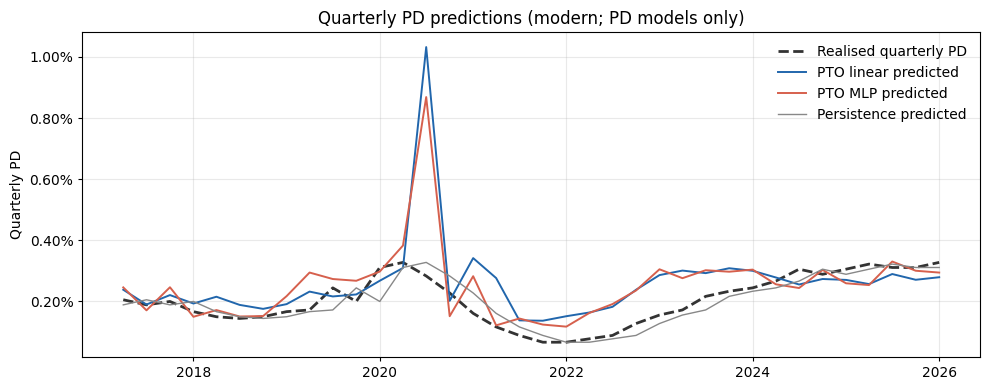

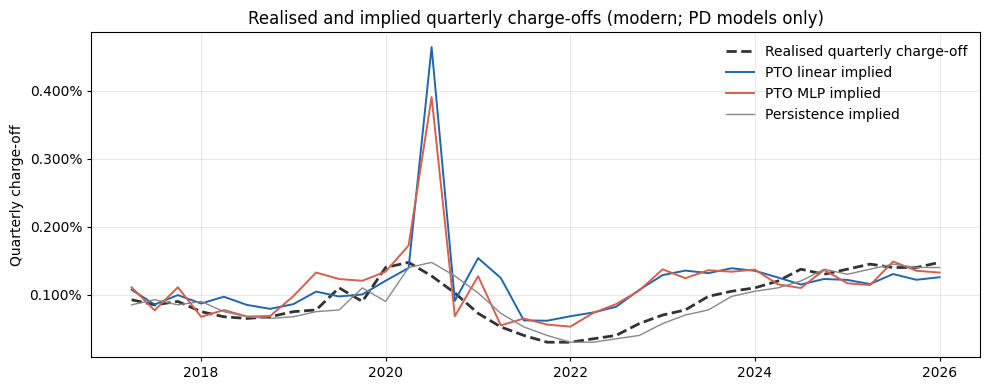

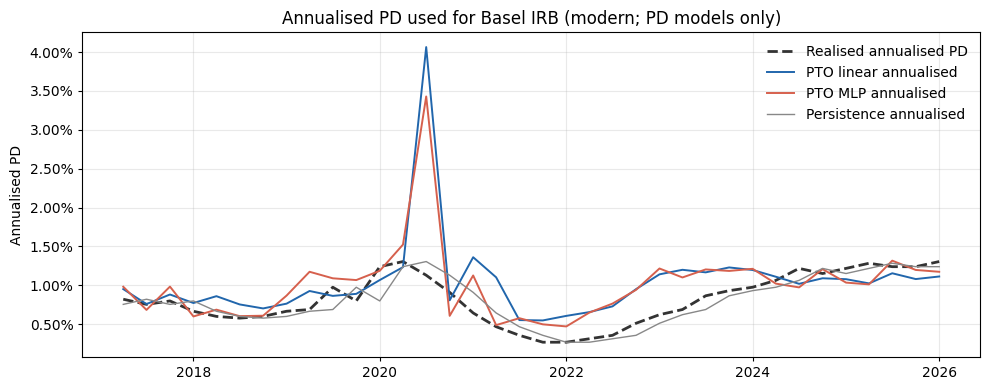

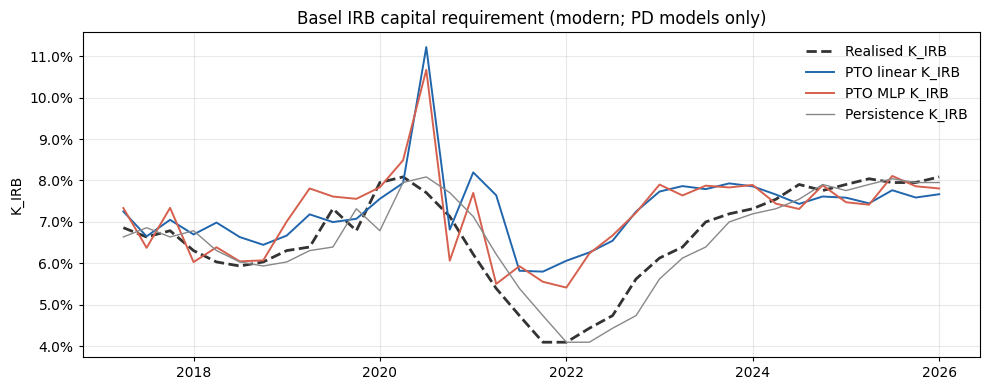

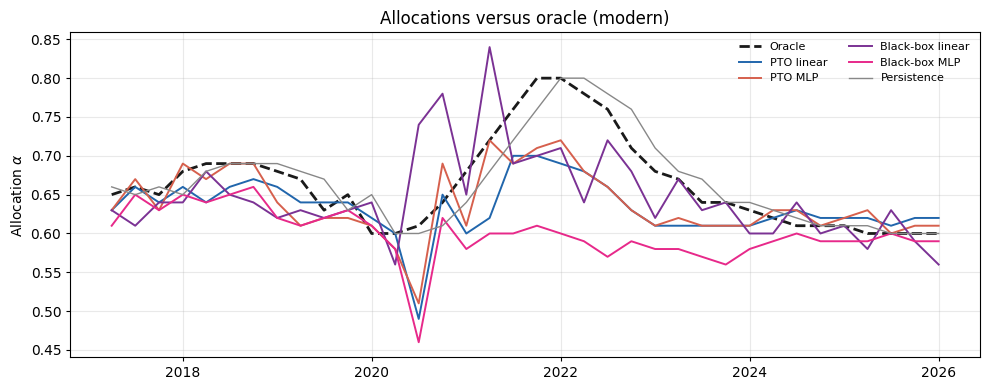

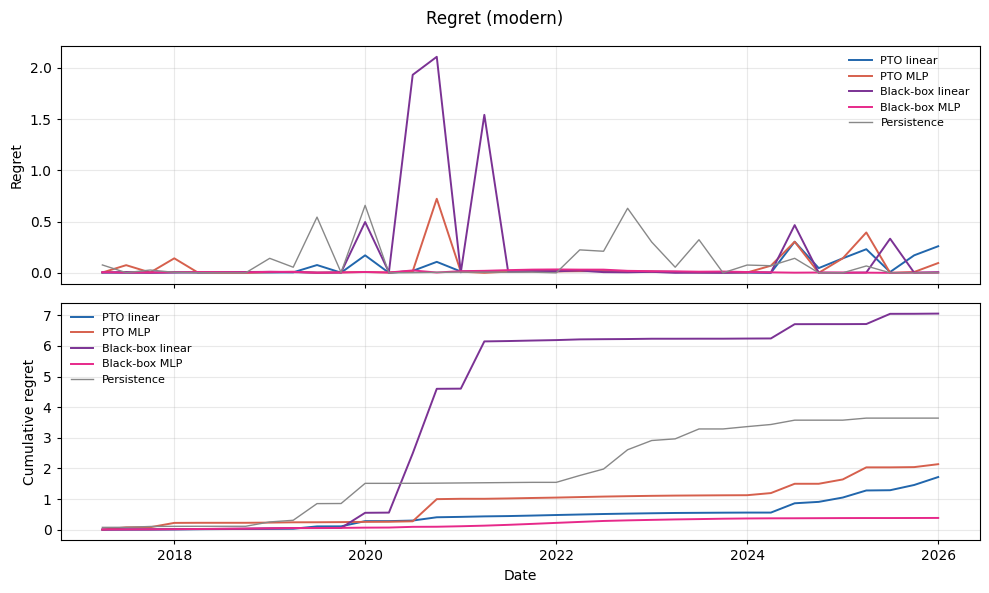

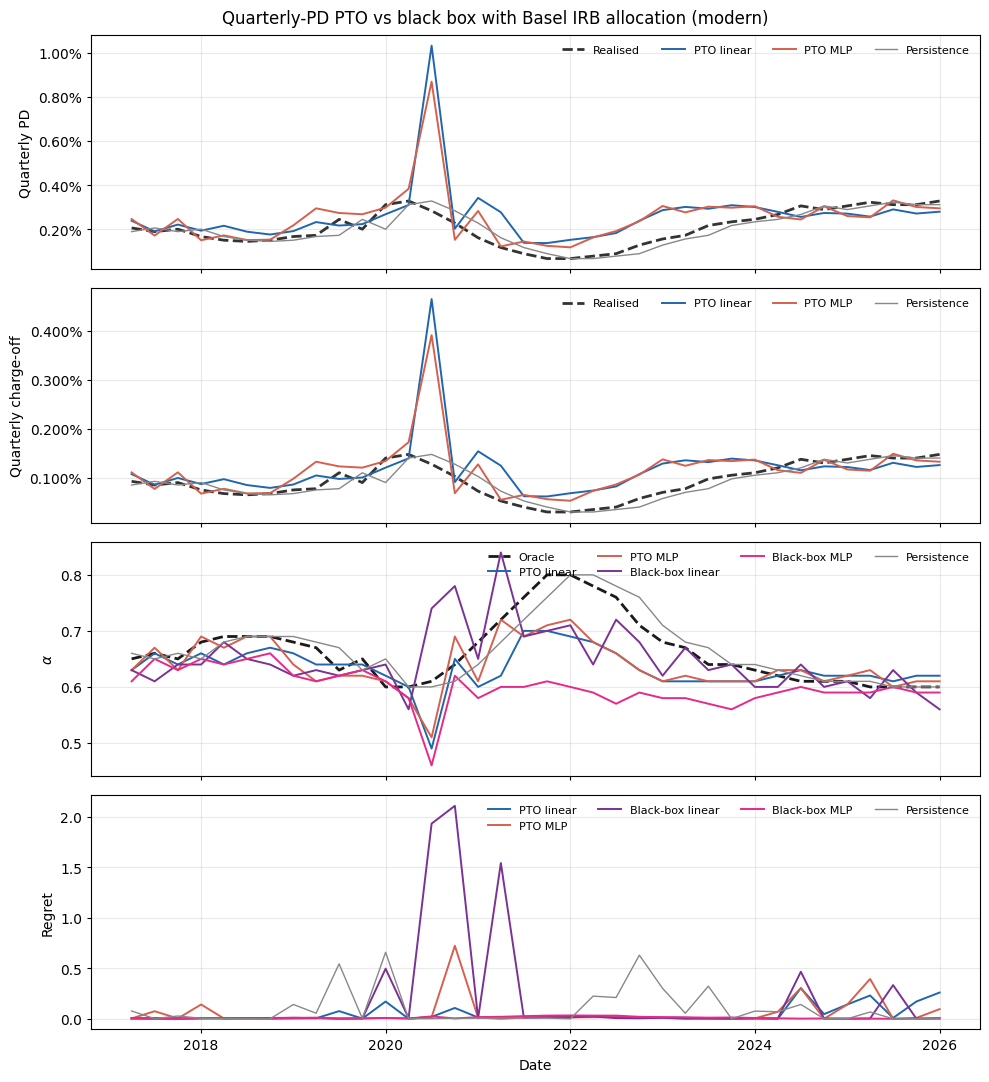

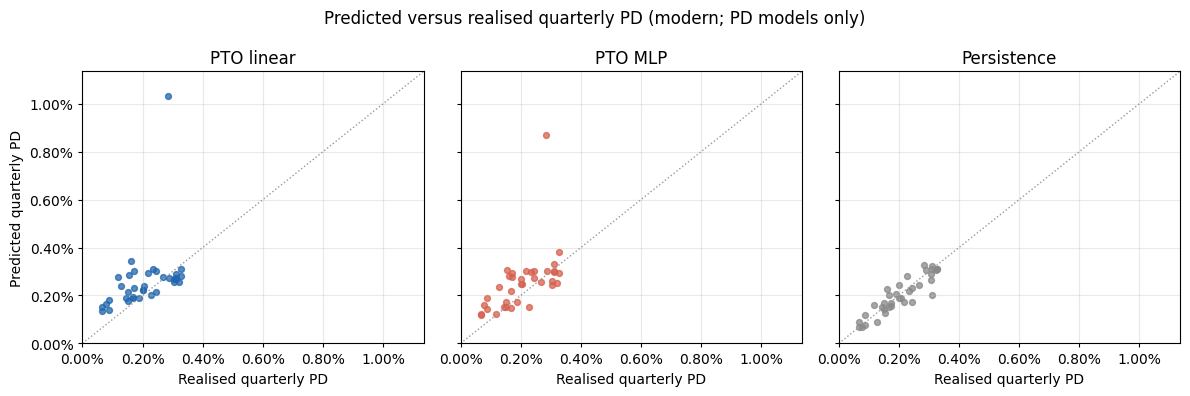

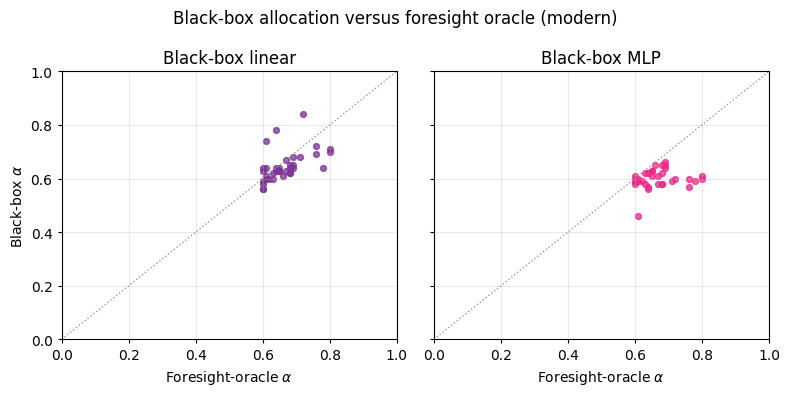

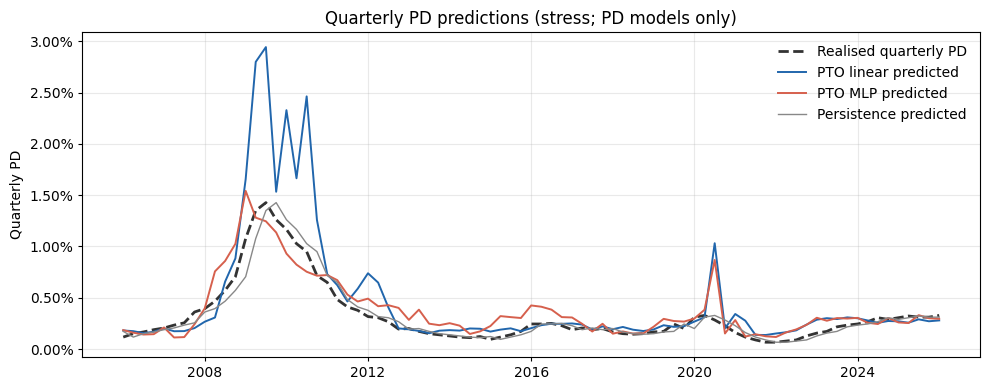

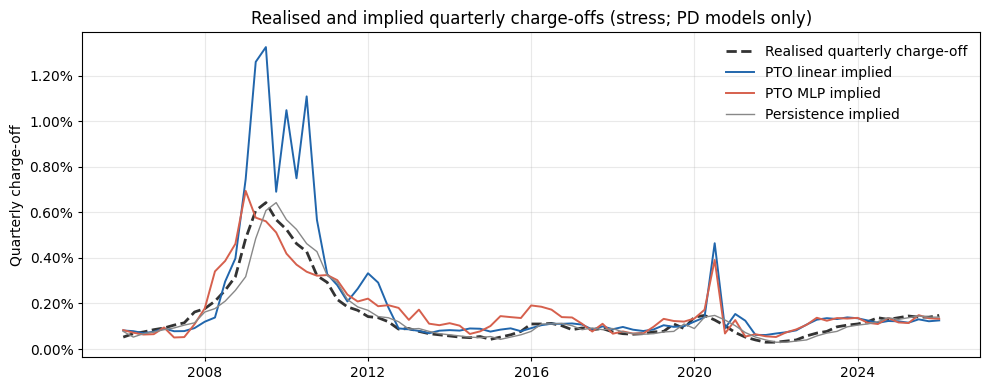

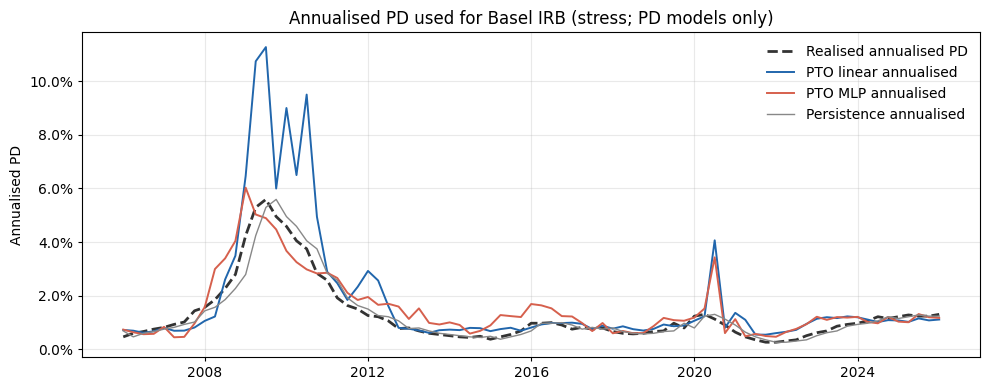

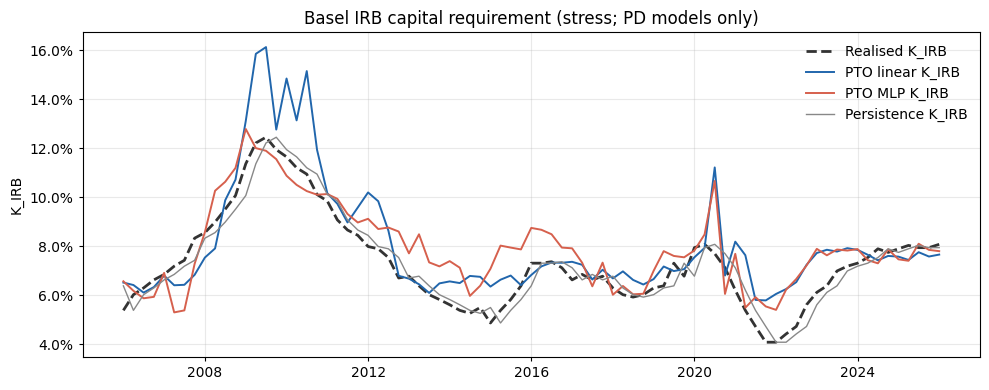

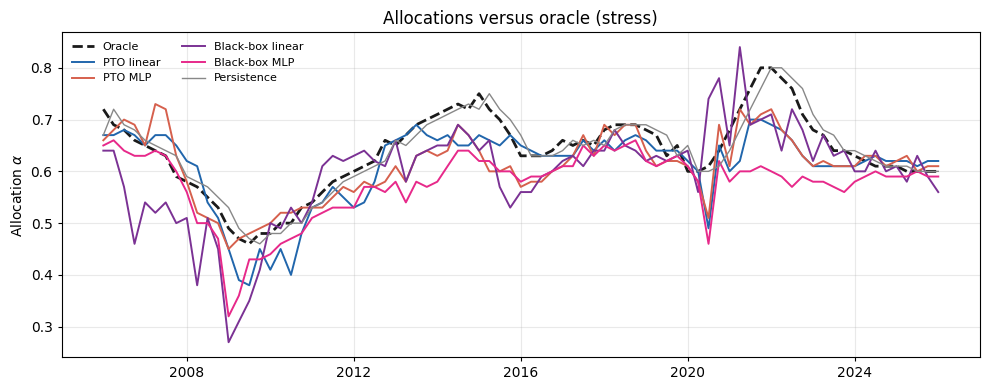

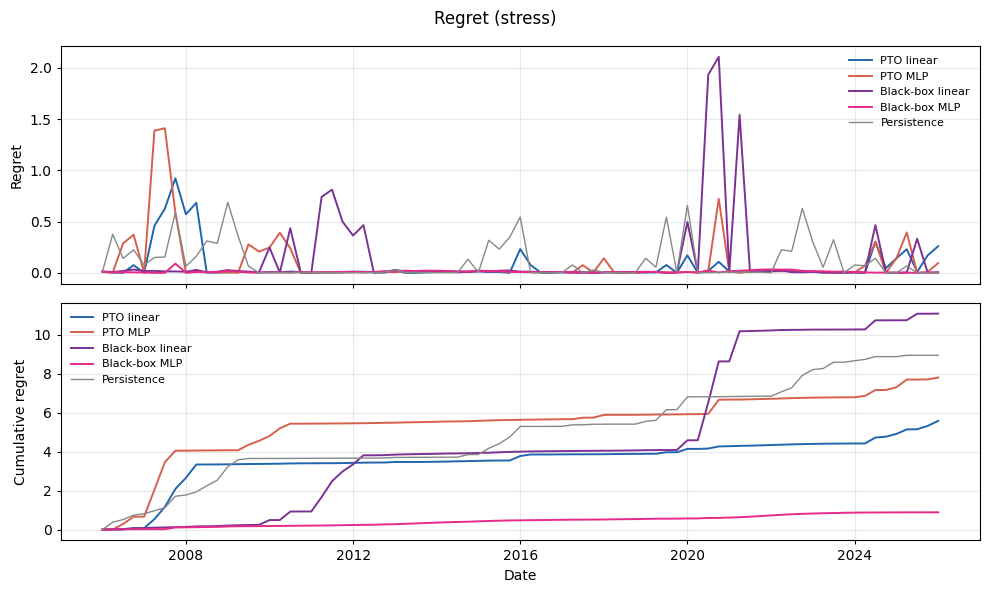

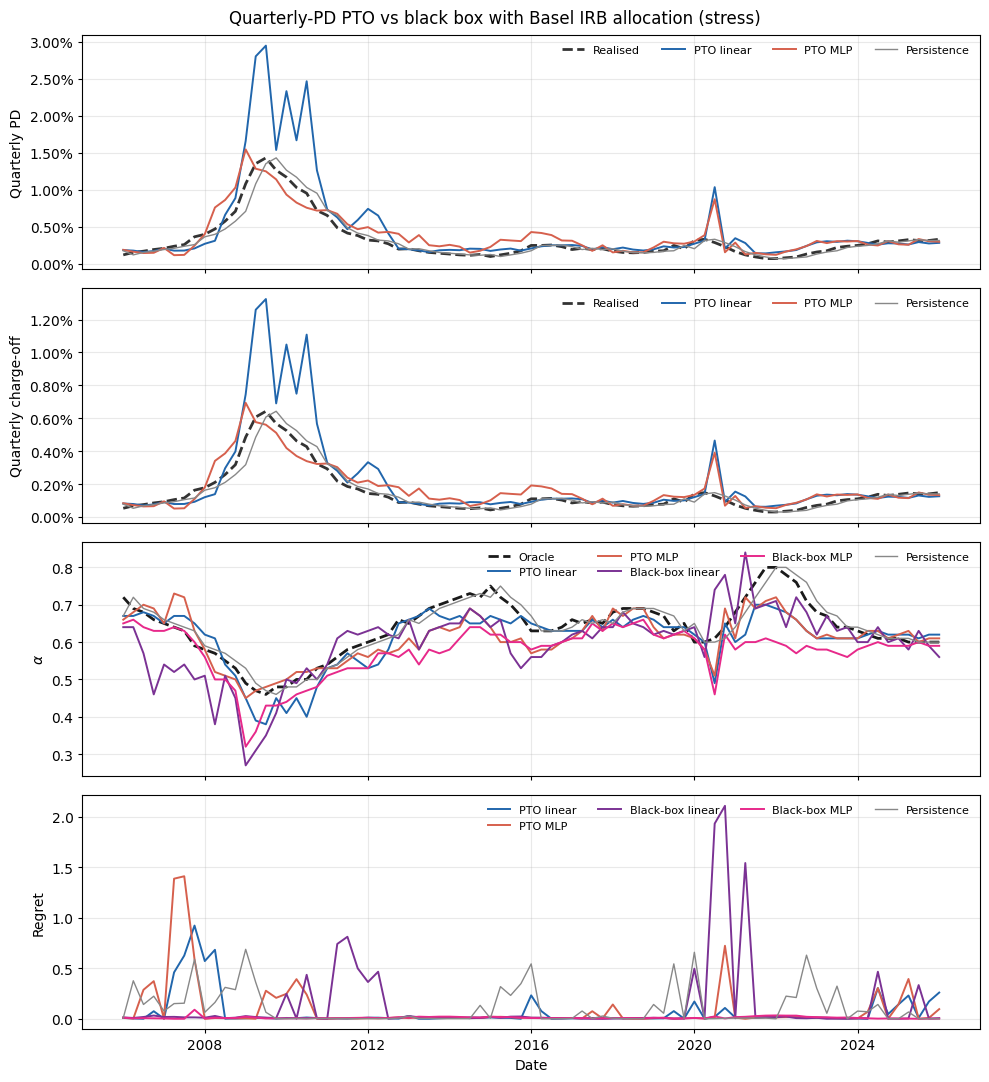

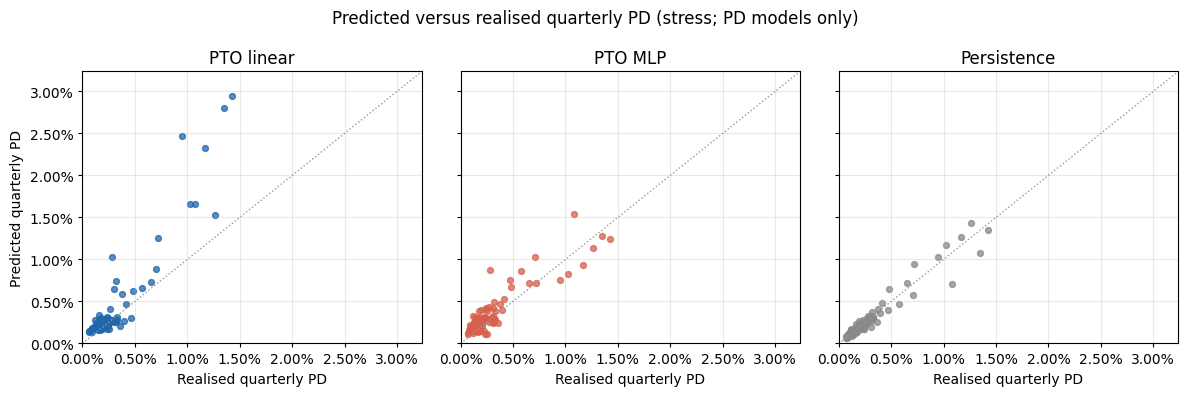

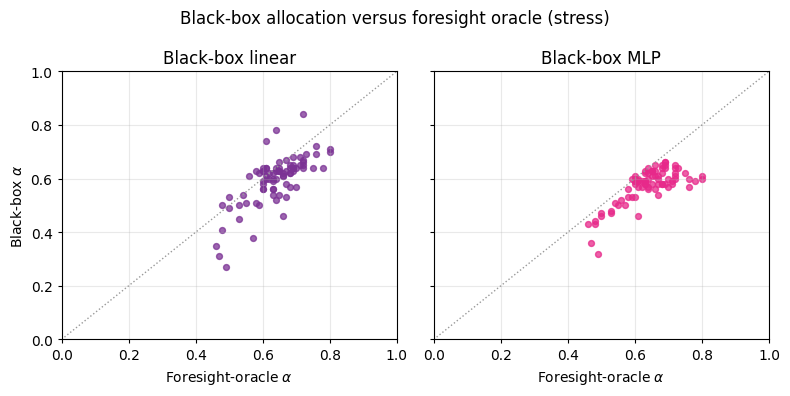

In [11]:
plt.rcdefaults()
plt.rcParams.update({"font.size": 10, "axes.linewidth": 0.8, "xtick.direction": "out", "ytick.direction": "out",
                     "xtick.major.size": 3, "ytick.major.size": 3, "font.sans-serif": ["DejaVu Sans"]})
from minou_colors import MINOU_COLORS
MODEL_COLORS = {"linear": MINOU_COLORS["teal"], "mlp": MINOU_COLORS["coral"], "blackbox_linear": MINOU_COLORS["navy"],
                "blackbox_mlp": MINOU_COLORS["sage"], "persistence": MINOU_COLORS["grey"]}
MODEL_LW = {"linear": 1.4, "mlp": 1.4, "blackbox_linear": 1.4, "blackbox_mlp": 1.4, "persistence": 1.0}
MODEL_LABELS = {"linear": "PTO linear", "mlp": "PTO MLP", "blackbox_linear": "Black-box linear",
                "blackbox_mlp": "Black-box MLP", "persistence": "Persistence"}
ORACLE_COLOR = MINOU_COLORS["navy"]
REAL_COLOR = MINOU_COLORS["grey"]

# Which models appear in the static figures. Any subset of MODEL_ORDER works, including
# black-box-only: PD-based panels are skipped when no PD model is selected.
PLOT_MODELS = ["linear", "mlp", "blackbox_linear", "blackbox_mlp", "persistence"]
PLOT_MODELS_PD = [m for m in PLOT_MODELS if m in PD_MODELS]
PLOT_MODELS_BB = [m for m in PLOT_MODELS if m in BB_MODELS]

def format_date_axis(ax, year_step=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(year_step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, alpha=0.28)


def _model_lines(ax, plot_df, col_prefix, suffix="", models=None):
    for m in (PLOT_MODELS if models is None else models):
        ax.plot(plot_df["date"], plot_df[f"{col_prefix}_{m}"], color=MODEL_COLORS[m],
                lw=MODEL_LW[m], label=f"{MODEL_LABELS[m]}{suffix}")


def plot_split(res, split_name):
    fig_dir = FIGURES_DIR / split_name
    fig_dir.mkdir(parents=True, exist_ok=True)
    plot_df = res.sort_values("date").copy()
    year_step = 2 if len(plot_df) <= 60 else 4

    if PLOT_MODELS_PD:
        # 1. Quarterly PD predictions (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly PD")
        _model_lines(ax, plot_df, "pd_q_hat", " predicted", models=PLOT_MODELS_PD)
        ax.set_ylabel("Quarterly PD"); ax.set_title(f"Quarterly PD predictions ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
        plt.savefig(fig_dir / "quarterly_pd_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

        # 2. Quarterly charge-off predictions (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised quarterly charge-off")
        _model_lines(ax, plot_df, "c_q_hat", " implied", models=PLOT_MODELS_PD)
        ax.set_ylabel("Quarterly charge-off"); ax.set_title(f"Realised and implied quarterly charge-offs ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
        plt.savefig(fig_dir / "quarterly_chargeoff_predictions.png", dpi=200, bbox_inches="tight"); plt.show()

        # 3. Annualised PD for IRB (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["pd_a_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised annualised PD")
        _model_lines(ax, plot_df, "pd_a_hat", " annualised", models=PLOT_MODELS_PD)
        ax.set_ylabel("Annualised PD"); ax.set_title(f"Annualised PD used for Basel IRB ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
        plt.savefig(fig_dir / "annualised_pd_irb.png", dpi=200, bbox_inches="tight"); plt.show()

        # 4. IRB capital requirement (PD models only)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(plot_df["date"], plot_df["k_irb_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised K_IRB")
        _model_lines(ax, plot_df, "k_irb_hat", " K_IRB", models=PLOT_MODELS_PD)
        ax.set_ylabel("K_IRB"); ax.set_title(f"Basel IRB capital requirement ({split_name}; PD models only)")
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
        format_date_axis(ax, year_step); ax.legend(frameon=False); plt.tight_layout()
        plt.savefig(fig_dir / "irb_capital_requirement.png", dpi=200, bbox_inches="tight"); plt.show()
    else:
        print(f"[{split_name}] no PD models in PLOT_MODELS - skipping PD, charge-off, K_IRB and PD-scatter figures.")

    # 5. Allocation comparison (all selected models)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(ax, plot_df, "alpha_hat")
    ax.set_ylabel(r"Allocation $\alpha$"); ax.set_title(f"Allocations versus oracle ({split_name})")
    format_date_axis(ax, year_step); ax.legend(frameon=False, fontsize=8, ncol=2); plt.tight_layout()
    plt.savefig(fig_dir / "allocation_comparison.png", dpi=200, bbox_inches="tight"); plt.show()

    # 6. Regret and cumulative regret (all selected models)
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    for m in PLOT_MODELS:
        axes[0].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
        axes[1].plot(plot_df["date"], plot_df[f"regret_{m}"].cumsum(), color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[0].set_ylabel("Regret"); axes[0].legend(frameon=False, fontsize=8)
    axes[1].set_ylabel("Cumulative regret"); axes[1].set_xlabel("Date"); axes[1].legend(frameon=False, fontsize=8)
    for ax in axes:
        format_date_axis(ax, year_step)
    fig.suptitle(f"Regret ({split_name})"); plt.tight_layout()
    plt.savefig(fig_dir / "regret.png", dpi=200, bbox_inches="tight"); plt.show()

    # 7. Compact 4-panel thesis figure (PD rows show PD models only; empty when none selected)
    fig, axes = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
    fig.subplots_adjust(hspace=0.08)
    axes[0].plot(plot_df["date"], plot_df["pd_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[0], plot_df, "pd_q_hat", models=PLOT_MODELS_PD)
    axes[0].set_ylabel("Quarterly PD"); axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[1].plot(plot_df["date"], plot_df["c_q_realised"], color=REAL_COLOR, lw=2, ls="--", label="Realised")
    _model_lines(axes[1], plot_df, "c_q_hat", models=PLOT_MODELS_PD)
    axes[1].set_ylabel("Quarterly charge-off"); axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[2].plot(plot_df["date"], plot_df["alpha_oracle"], color=ORACLE_COLOR, lw=2, ls="--", label="Oracle")
    _model_lines(axes[2], plot_df, "alpha_hat")
    axes[2].set_ylabel(r"$\alpha$")
    for m in PLOT_MODELS:
        axes[3].plot(plot_df["date"], plot_df[f"regret_{m}"], color=MODEL_COLORS[m], lw=MODEL_LW[m], label=MODEL_LABELS[m])
    axes[3].set_ylabel("Regret"); axes[3].set_xlabel("Date")
    for ax in axes:
        format_date_axis(ax, year_step); ax.legend(fontsize=8, frameon=False, loc="upper right", ncol=4)
    fig.suptitle(f"Quarterly-PD PTO vs black box with Basel IRB allocation ({split_name})", fontsize=12)
    plt.tight_layout(); plt.savefig(fig_dir / "blackbox_pd_irb_compact_panel.png", dpi=220, bbox_inches="tight"); plt.show()

    # 8. Predicted vs realised scatter (PD models only - skipped when none selected)
    if PLOT_MODELS_PD:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_PD), figsize=(4 * len(PLOT_MODELS_PD), 4), sharex=True, sharey=True)
        lims = [0.0, max(plot_df["pd_q_realised"].max(), *(plot_df[f"pd_q_hat_{m}"].max() for m in PLOT_MODELS_PD)) * 1.1]
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_PD):
            ax.scatter(plot_df["pd_q_realised"], plot_df[f"pd_q_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
            ax.plot(lims, lims, color=MINOU_COLORS["grey"], lw=1, ls=":")
            ax.set_xlim(lims); ax.set_ylim(lims)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel("Realised quarterly PD")
            ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel("Predicted quarterly PD")
        fig.suptitle(f"Predicted versus realised quarterly PD ({split_name}; PD models only)")
        plt.tight_layout(); plt.savefig(fig_dir / "pred_vs_realised_scatter.png", dpi=200, bbox_inches="tight"); plt.show()

    # 9. Black-box alpha vs oracle alpha scatter (skipped when no black-box model selected)
    if PLOT_MODELS_BB:
        fig, axes = plt.subplots(1, len(PLOT_MODELS_BB), figsize=(4 * len(PLOT_MODELS_BB), 4), sharex=True, sharey=True)
        for ax, m in zip(np.atleast_1d(axes), PLOT_MODELS_BB):
            ax.scatter(plot_df["alpha_oracle"], plot_df[f"alpha_hat_{m}"], s=18, color=MODEL_COLORS[m], alpha=0.75)
            ax.plot([0, 1], [0, 1], color=MINOU_COLORS["grey"], lw=1, ls=":")
            ax.set_xlim(0, 1); ax.set_ylim(0, 1)
            ax.set_title(MODEL_LABELS[m]); ax.set_xlabel(r"Foresight-oracle $\alpha$")
            ax.grid(True, alpha=0.28)
        np.atleast_1d(axes)[0].set_ylabel(r"Black-box $\alpha$")
        fig.suptitle(f"Black-box allocation versus foresight oracle ({split_name})")
        plt.tight_layout(); plt.savefig(fig_dir / "bb_alpha_vs_oracle_scatter.png", dpi=200, bbox_inches="tight"); plt.show()


for split_name, res in results_by_split.items():
    plot_split(res, split_name)


## Learning curves

Averaged across expanding windows within each split; the MLP curve is the first ensemble
seed only.
Early-stopped windows are padded by carrying the last value forward so the per-epoch mean
keeps constant composition. The black box gets its own panel: validation REGRET, its
early-stopping criterion (the PD models' panels show validation RMSE and validation loss
in the training space).


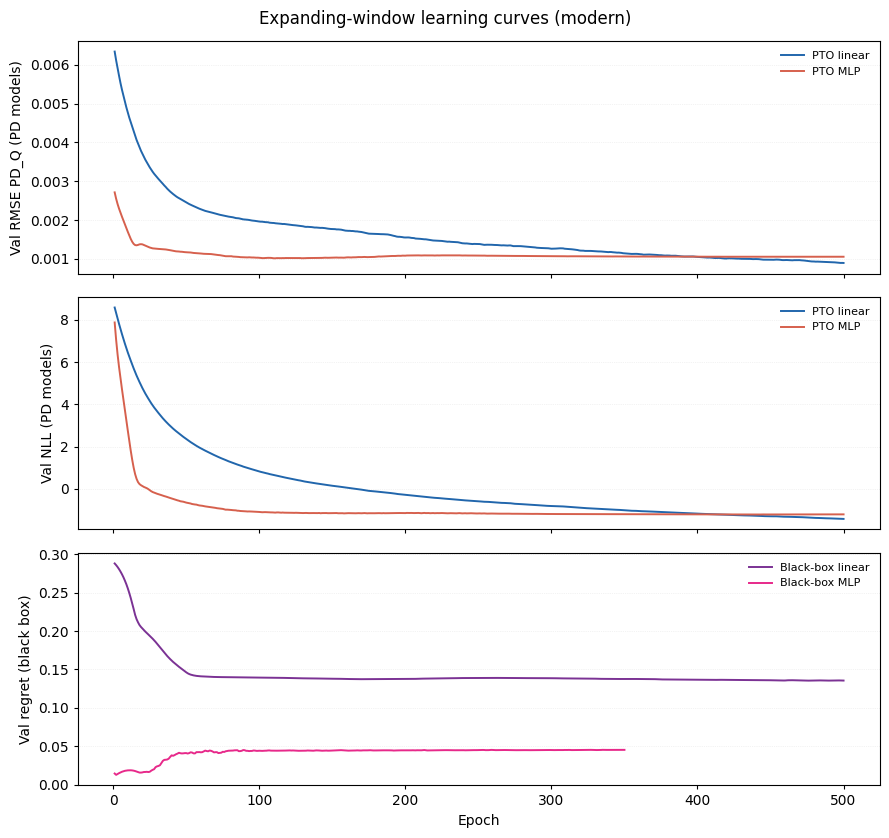

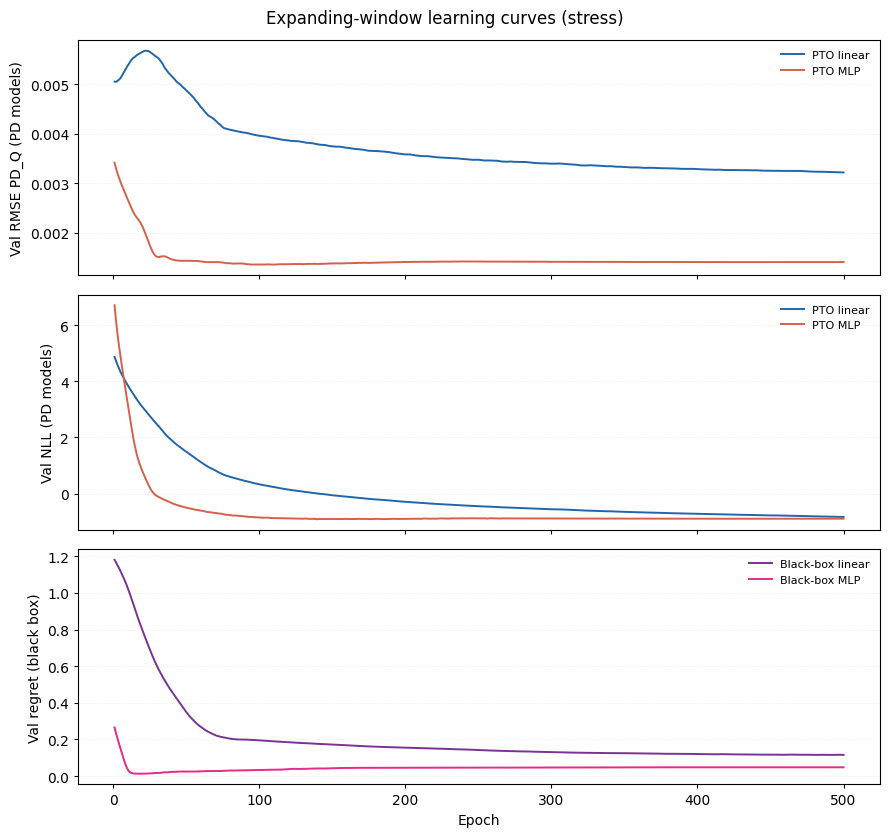

In [12]:
if not training_history.empty:
    for split_name, split_hist in training_history.groupby("split"):
        # Pad each refit's history to the model's max epoch (last value carried forward)
        # so the per-epoch mean has constant composition despite early stopping.
        padded = []
        for model_name, mg in split_hist.groupby("model"):
            max_epoch = int(mg["epoch"].max())
            for _, g in mg.groupby("test_date"):
                gg = (g.sort_values("epoch").set_index("epoch")[["val_rmse_pd_q", "val_loss"]]
                       .reindex(range(1, max_epoch + 1)).ffill().reset_index())
                gg["model"] = model_name
                padded.append(gg)
        mean_history = (pd.concat(padded, ignore_index=True)
                        .groupby(["model", "epoch"], as_index=False)
                        .agg(mean_val_rmse_pd_q=("val_rmse_pd_q", "mean"), mean_val_loss=("val_loss", "mean")))

        fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
        for model_name, group in mean_history.groupby("model"):
            group = group.sort_values("epoch"); color = MODEL_COLORS.get(model_name, "grey")
            label = MODEL_LABELS.get(model_name, model_name.upper())
            if model_name in BB_MODELS:
                axes[2].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
            elif model_name in ("linear", "mlp"):
                axes[0].plot(group["epoch"], group["mean_val_rmse_pd_q"], color=color, lw=1.4, label=label)
                axes[1].plot(group["epoch"], group["mean_val_loss"], color=color, lw=1.4, label=label)
        axes[0].set_ylabel("Val RMSE PD_Q (PD models)")
        loss_space = "NLL" if LOSS == "nll_vasicek" else f"MSE ({TARGET_TRANSFORM} space)"
        axes[1].set_ylabel(f"Val {loss_space} (PD models)")
        axes[2].set_ylabel("Val regret (black box)"); axes[2].set_xlabel("Epoch")
        for ax in axes:
            ax.grid(True, axis="y", lw=0.5, alpha=0.3, linestyle=":"); ax.legend(fontsize=8, frameon=False, loc="upper right")
        fig.suptitle(f"Expanding-window learning curves ({split_name})"); plt.tight_layout()
        fig_dir = FIGURES_DIR / split_name
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / "learning_curves.png", dpi=200, bbox_inches="tight"); plt.show()
